In [1]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image
from scipy.io import savemat

import time
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from cimCommand import CMD,CmdData,Packet
from cimCommand.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar

In [2]:
def npy_to_csv(npy_path,csv_path):
    loaded_array = np.load(npy_path,allow_pickle=True)
    np.savetxt(csv_path, loaded_array, delimiter=',', fmt='%.4f')

def npy_to_mat(npy_path,mat_path):
    data = np.load(npy_path)
    savemat(mat_path, {"data": data})

In [ ]:
cond_sub_base = np.load("./result/best_img/cond_sub_base2.npy",allow_pickle=True)

path = "./result/best_img/result.png"
cmap = plt.cm.viridis
norm = Normalize(vmin=0, vmax=1000)
im = plt.imshow(np.array(cond_sub_base), cmap=cmap,norm=norm)
cbar = plt.colorbar(im)
cbar.set_label("us")
plt.title(f"result")
plt.savefig(path)
plt.show()

# npy_to_csv(root_path+f"after_write_verify_time={i}.npy",root_path+f"{i}.csv")

In [ ]:
root_path = "./result/write_verify_12_22_8/"
for i in range(41):
    cond_sub_base = np.load(root_path+f"after_write_verify_time={i}.npy",allow_pickle=True)

    path = root_path+f"{i}_noTitle.png"
    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=1000)
    im = plt.imshow(np.array(cond_sub_base), cmap=cmap,norm=norm)
    cbar = plt.colorbar(im)
    cbar.set_label("us")
    plt.title(f"write = {i}")
    plt.savefig(path)
    plt.show()

    npy_to_csv(root_path+f"after_write_verify_time={i}.npy",root_path+f"{i}.csv")


In [ ]:
target = 175
for i in range(16):
    target = target+50
    cond_sub_base_path = []
    good_device_path = []
    root_path=f"./result/5bit精度/{target}us/"
    for i in range(30):
        cond_sub_base_path.append(root_path+f"after_write_verify_time={int(i)}.npy")
        good_device_path.append(root_path+"good_device.npy")
    print(cond_sub_base_path)

    interval = 5
    bin_edges = np.linspace(0, 2000, int(2000/interval)+1)  
    for i,path in enumerate(cond_sub_base_path):
        good_device = np.load(good_device_path[i])
        cond_sub_base = np.load(path)[good_device]
        data = cond_sub_base.flatten()
        counts, bin_edges, _ = plt.hist(data, bins=bin_edges, color='blue', alpha=0.7, edgecolor='black')
        plt.title(f"target = {target},write = {i}")
        plt.xlabel("cond(uS)")
        plt.ylabel("Frequency")
        path = root_path+f"target = {target},write = {i}.png"
        plt.savefig(path)
        plt.show()

In [ ]:
target = target+50
cond_sub_base_path = []
good_device_path = []
root_path=f"./result/5bit精度/{target}us/"
for i in range(30):
    cond_sub_base_path.append(root_path+f"after_write_verify_time={int(i)}.npy")
    good_device_path.append(root_path+"good_device.npy")
print(cond_sub_base_path)

interval = 5
bin_edges = np.linspace(0, 2000, int(2000/interval)+1)  
for i,path in enumerate(cond_sub_base_path):
    good_device = np.load(good_device_path[i])
    cond_sub_base = np.load(path)[good_device]
    data = cond_sub_base.flatten()
    counts, bin_edges, _ = plt.hist(data, bins=bin_edges, color='blue', alpha=0.7, edgecolor='black')
    plt.title(f"target = {target},write = {i}")
    plt.xlabel("cond(uS)")
    plt.ylabel("Frequency")
    path = root_path+f"target = {target},write = {i}.png"
    plt.savefig(path)
    plt.show()

In [ ]:
times = 30
target = 175
cond_sub_base_path = []
good_device_path = []
for i in range(15):
    target = target+50

    root_path=f"./result/5bit精度/{target}us/"
    cond_sub_base_path.append(root_path+f"after_write_verify_time={times}.npy")
    good_device_path.append(root_path+"good_device.npy")
print(cond_sub_base_path)
print(good_device_path)

['./result/5bit精度/225us/after_write_verify_time=1.npy', './result/5bit精度/250us/after_write_verify_time=1.npy', './result/5bit精度/275us/after_write_verify_time=1.npy', './result/5bit精度/300us/after_write_verify_time=1.npy', './result/5bit精度/325us/after_write_verify_time=1.npy', './result/5bit精度/350us/after_write_verify_time=1.npy', './result/5bit精度/375us/after_write_verify_time=1.npy', './result/5bit精度/400us/after_write_verify_time=1.npy', './result/5bit精度/425us/after_write_verify_time=1.npy', './result/5bit精度/450us/after_write_verify_time=1.npy', './result/5bit精度/475us/after_write_verify_time=1.npy', './result/5bit精度/500us/after_write_verify_time=1.npy', './result/5bit精度/525us/after_write_verify_time=1.npy', './result/5bit精度/550us/after_write_verify_time=1.npy', './result/5bit精度/575us/after_write_verify_time=1.npy', './result/5bit精度/600us/after_write_verify_time=1.npy', './result/5bit精度/625us/after_write_verify_time=1.npy', './result/5bit精度/650us/after_write_verify_time=1.npy', './result

C:\Users\CCNTL\AppData\Local\Temp\ipykernel_24456\3431803215.py:36: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("./result/器件性能5bit/"+f"points_num = {4614},write = {times}.png")


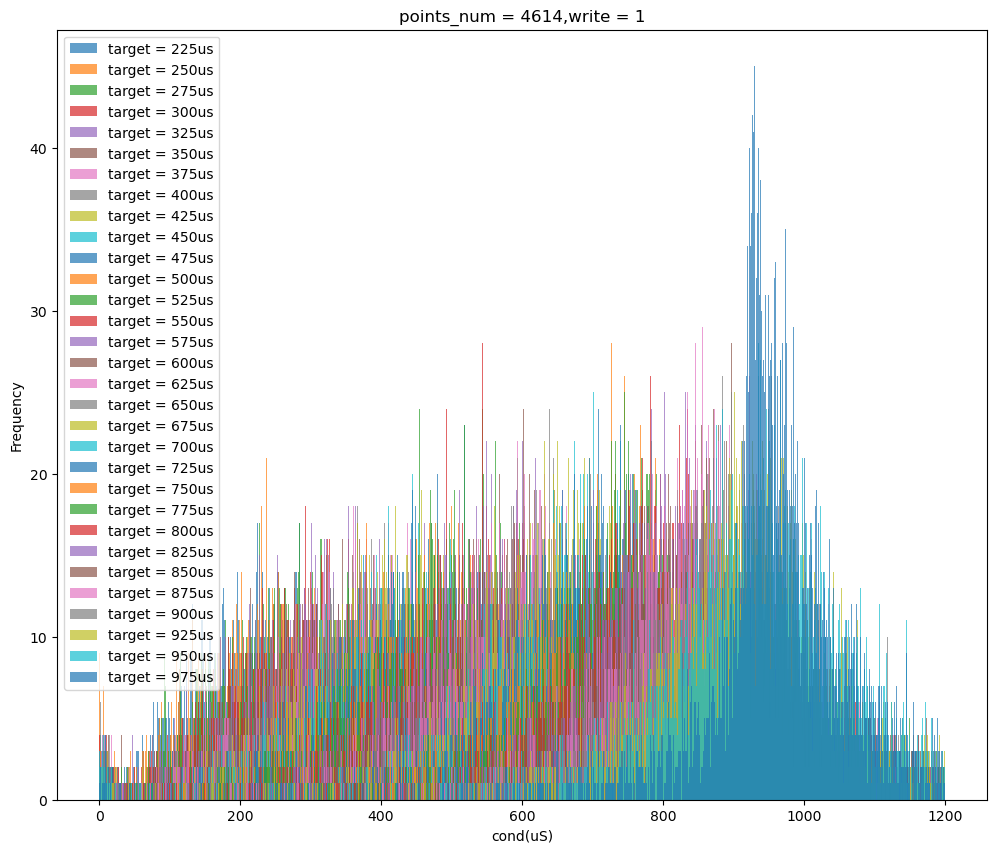

['./result/5bit精度/225us/after_write_verify_time=2.npy', './result/5bit精度/250us/after_write_verify_time=2.npy', './result/5bit精度/275us/after_write_verify_time=2.npy', './result/5bit精度/300us/after_write_verify_time=2.npy', './result/5bit精度/325us/after_write_verify_time=2.npy', './result/5bit精度/350us/after_write_verify_time=2.npy', './result/5bit精度/375us/after_write_verify_time=2.npy', './result/5bit精度/400us/after_write_verify_time=2.npy', './result/5bit精度/425us/after_write_verify_time=2.npy', './result/5bit精度/450us/after_write_verify_time=2.npy', './result/5bit精度/475us/after_write_verify_time=2.npy', './result/5bit精度/500us/after_write_verify_time=2.npy', './result/5bit精度/525us/after_write_verify_time=2.npy', './result/5bit精度/550us/after_write_verify_time=2.npy', './result/5bit精度/575us/after_write_verify_time=2.npy', './result/5bit精度/600us/after_write_verify_time=2.npy', './result/5bit精度/625us/after_write_verify_time=2.npy', './result/5bit精度/650us/after_write_verify_time=2.npy', './result

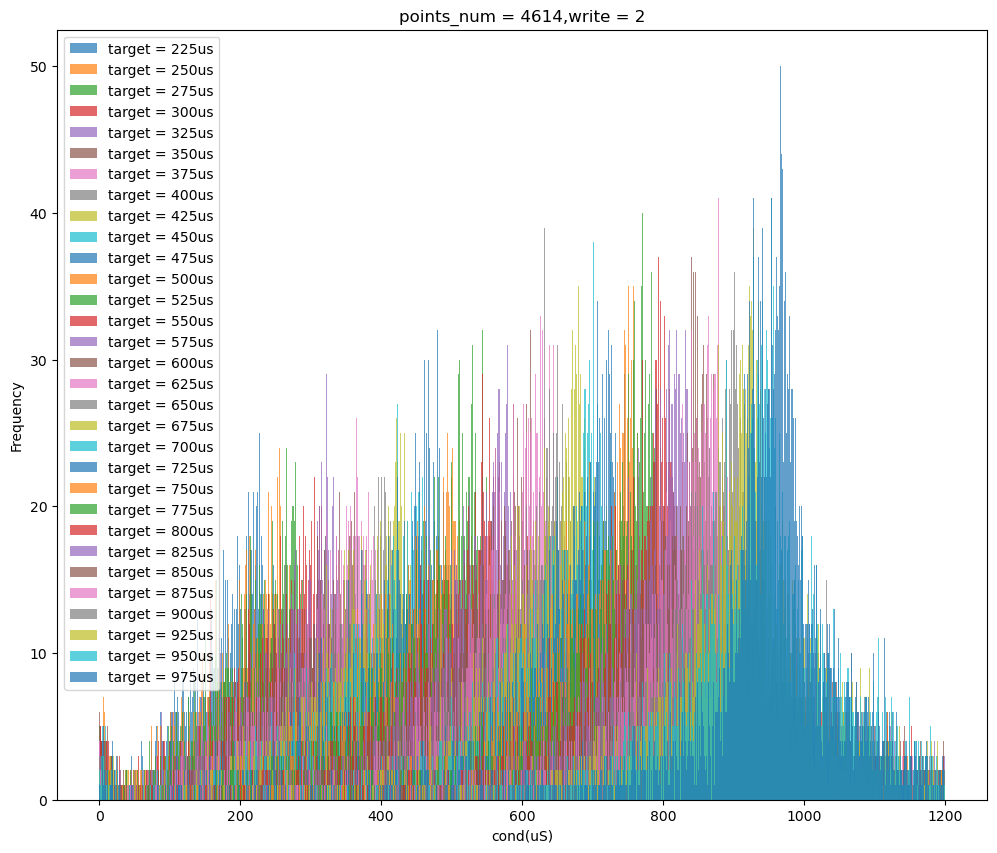

['./result/5bit精度/225us/after_write_verify_time=3.npy', './result/5bit精度/250us/after_write_verify_time=3.npy', './result/5bit精度/275us/after_write_verify_time=3.npy', './result/5bit精度/300us/after_write_verify_time=3.npy', './result/5bit精度/325us/after_write_verify_time=3.npy', './result/5bit精度/350us/after_write_verify_time=3.npy', './result/5bit精度/375us/after_write_verify_time=3.npy', './result/5bit精度/400us/after_write_verify_time=3.npy', './result/5bit精度/425us/after_write_verify_time=3.npy', './result/5bit精度/450us/after_write_verify_time=3.npy', './result/5bit精度/475us/after_write_verify_time=3.npy', './result/5bit精度/500us/after_write_verify_time=3.npy', './result/5bit精度/525us/after_write_verify_time=3.npy', './result/5bit精度/550us/after_write_verify_time=3.npy', './result/5bit精度/575us/after_write_verify_time=3.npy', './result/5bit精度/600us/after_write_verify_time=3.npy', './result/5bit精度/625us/after_write_verify_time=3.npy', './result/5bit精度/650us/after_write_verify_time=3.npy', './result

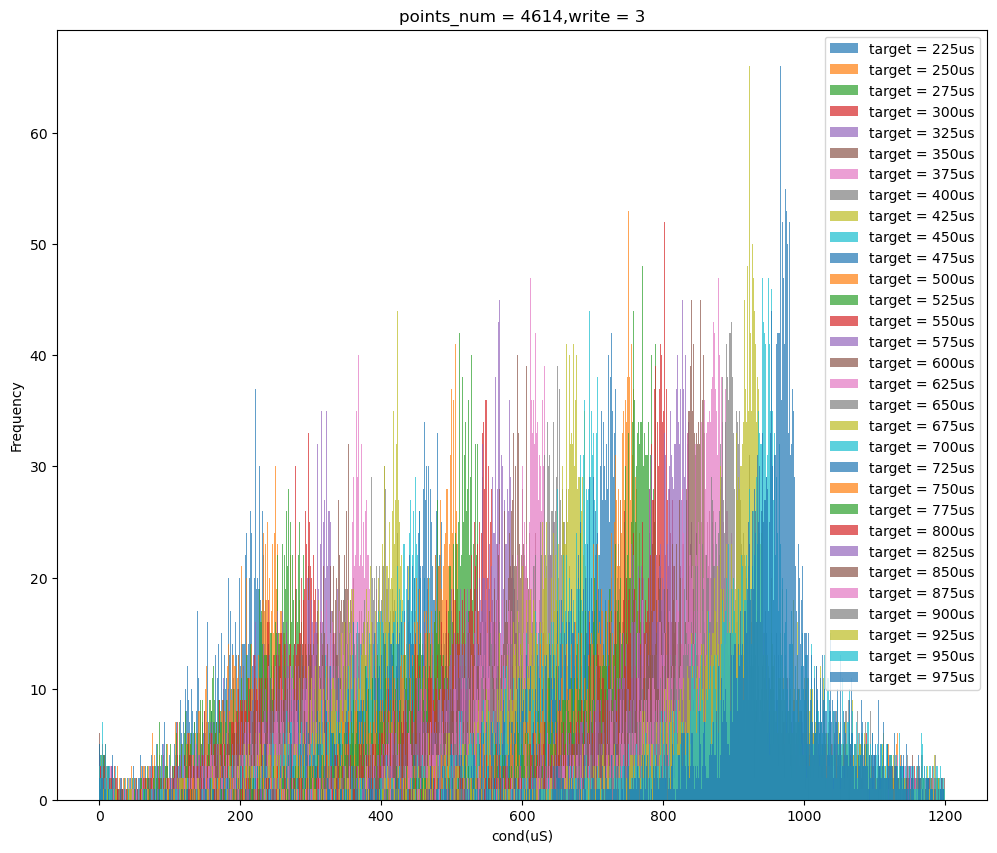

['./result/5bit精度/225us/after_write_verify_time=4.npy', './result/5bit精度/250us/after_write_verify_time=4.npy', './result/5bit精度/275us/after_write_verify_time=4.npy', './result/5bit精度/300us/after_write_verify_time=4.npy', './result/5bit精度/325us/after_write_verify_time=4.npy', './result/5bit精度/350us/after_write_verify_time=4.npy', './result/5bit精度/375us/after_write_verify_time=4.npy', './result/5bit精度/400us/after_write_verify_time=4.npy', './result/5bit精度/425us/after_write_verify_time=4.npy', './result/5bit精度/450us/after_write_verify_time=4.npy', './result/5bit精度/475us/after_write_verify_time=4.npy', './result/5bit精度/500us/after_write_verify_time=4.npy', './result/5bit精度/525us/after_write_verify_time=4.npy', './result/5bit精度/550us/after_write_verify_time=4.npy', './result/5bit精度/575us/after_write_verify_time=4.npy', './result/5bit精度/600us/after_write_verify_time=4.npy', './result/5bit精度/625us/after_write_verify_time=4.npy', './result/5bit精度/650us/after_write_verify_time=4.npy', './result

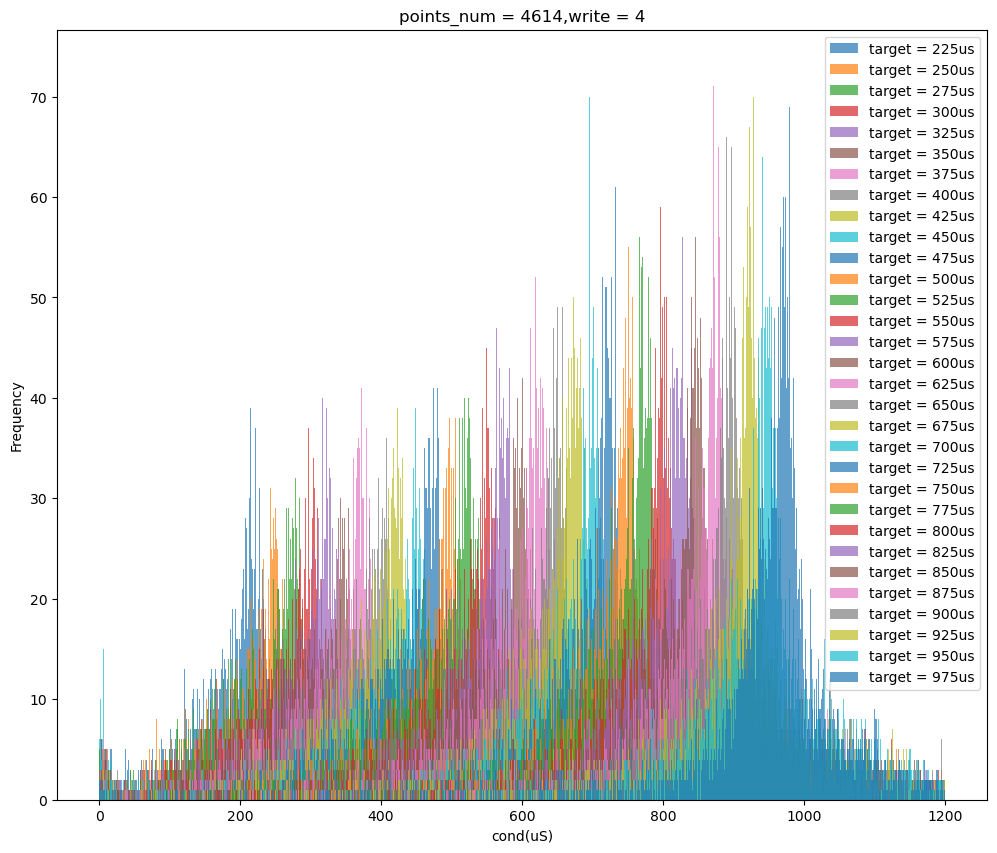

['./result/5bit精度/225us/after_write_verify_time=5.npy', './result/5bit精度/250us/after_write_verify_time=5.npy', './result/5bit精度/275us/after_write_verify_time=5.npy', './result/5bit精度/300us/after_write_verify_time=5.npy', './result/5bit精度/325us/after_write_verify_time=5.npy', './result/5bit精度/350us/after_write_verify_time=5.npy', './result/5bit精度/375us/after_write_verify_time=5.npy', './result/5bit精度/400us/after_write_verify_time=5.npy', './result/5bit精度/425us/after_write_verify_time=5.npy', './result/5bit精度/450us/after_write_verify_time=5.npy', './result/5bit精度/475us/after_write_verify_time=5.npy', './result/5bit精度/500us/after_write_verify_time=5.npy', './result/5bit精度/525us/after_write_verify_time=5.npy', './result/5bit精度/550us/after_write_verify_time=5.npy', './result/5bit精度/575us/after_write_verify_time=5.npy', './result/5bit精度/600us/after_write_verify_time=5.npy', './result/5bit精度/625us/after_write_verify_time=5.npy', './result/5bit精度/650us/after_write_verify_time=5.npy', './result

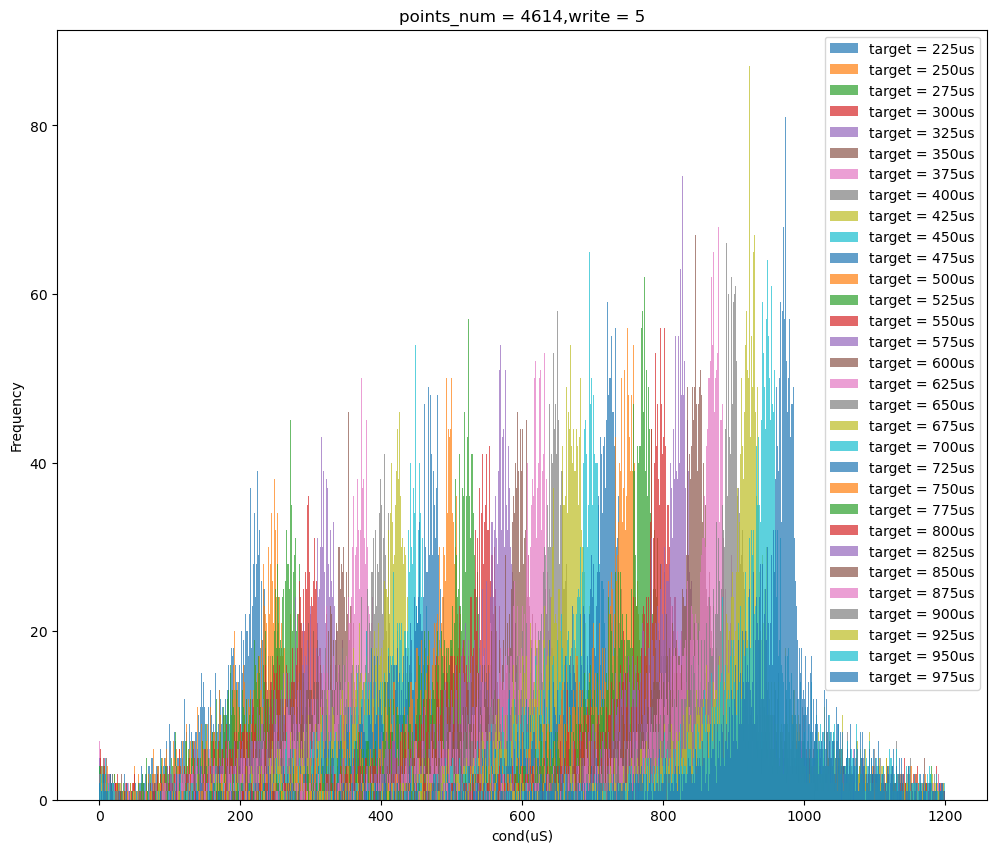

['./result/5bit精度/225us/after_write_verify_time=6.npy', './result/5bit精度/250us/after_write_verify_time=6.npy', './result/5bit精度/275us/after_write_verify_time=6.npy', './result/5bit精度/300us/after_write_verify_time=6.npy', './result/5bit精度/325us/after_write_verify_time=6.npy', './result/5bit精度/350us/after_write_verify_time=6.npy', './result/5bit精度/375us/after_write_verify_time=6.npy', './result/5bit精度/400us/after_write_verify_time=6.npy', './result/5bit精度/425us/after_write_verify_time=6.npy', './result/5bit精度/450us/after_write_verify_time=6.npy', './result/5bit精度/475us/after_write_verify_time=6.npy', './result/5bit精度/500us/after_write_verify_time=6.npy', './result/5bit精度/525us/after_write_verify_time=6.npy', './result/5bit精度/550us/after_write_verify_time=6.npy', './result/5bit精度/575us/after_write_verify_time=6.npy', './result/5bit精度/600us/after_write_verify_time=6.npy', './result/5bit精度/625us/after_write_verify_time=6.npy', './result/5bit精度/650us/after_write_verify_time=6.npy', './result

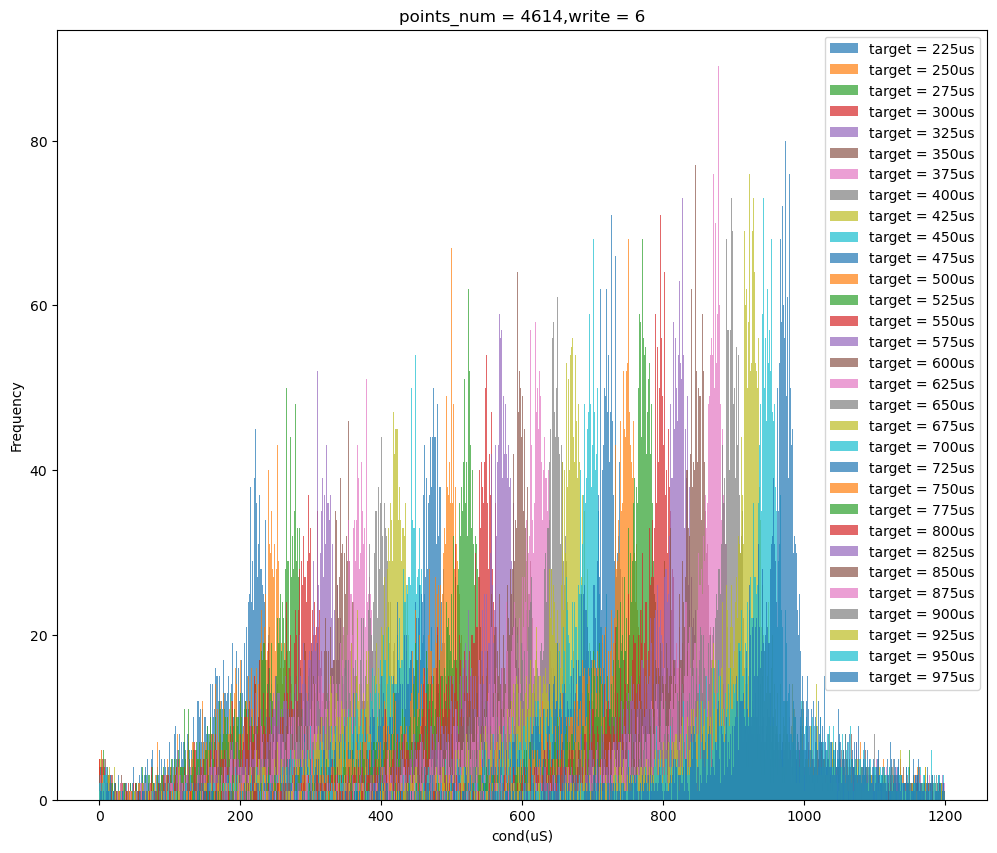

['./result/5bit精度/225us/after_write_verify_time=7.npy', './result/5bit精度/250us/after_write_verify_time=7.npy', './result/5bit精度/275us/after_write_verify_time=7.npy', './result/5bit精度/300us/after_write_verify_time=7.npy', './result/5bit精度/325us/after_write_verify_time=7.npy', './result/5bit精度/350us/after_write_verify_time=7.npy', './result/5bit精度/375us/after_write_verify_time=7.npy', './result/5bit精度/400us/after_write_verify_time=7.npy', './result/5bit精度/425us/after_write_verify_time=7.npy', './result/5bit精度/450us/after_write_verify_time=7.npy', './result/5bit精度/475us/after_write_verify_time=7.npy', './result/5bit精度/500us/after_write_verify_time=7.npy', './result/5bit精度/525us/after_write_verify_time=7.npy', './result/5bit精度/550us/after_write_verify_time=7.npy', './result/5bit精度/575us/after_write_verify_time=7.npy', './result/5bit精度/600us/after_write_verify_time=7.npy', './result/5bit精度/625us/after_write_verify_time=7.npy', './result/5bit精度/650us/after_write_verify_time=7.npy', './result

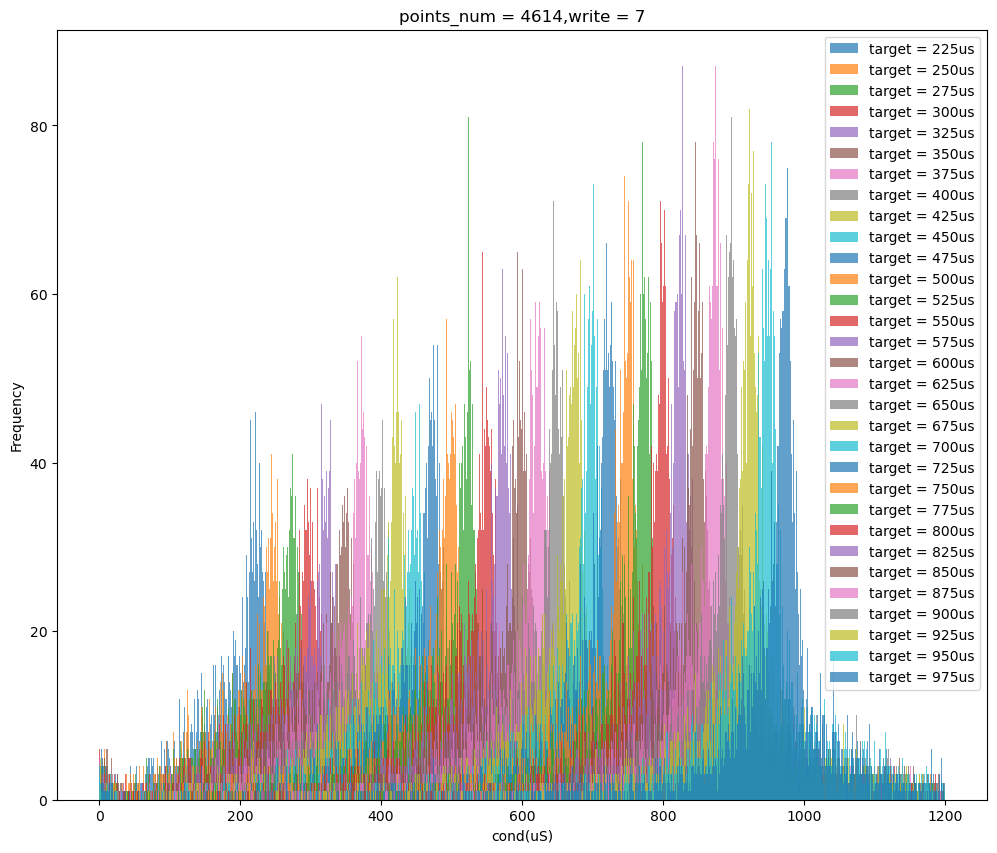

['./result/5bit精度/225us/after_write_verify_time=8.npy', './result/5bit精度/250us/after_write_verify_time=8.npy', './result/5bit精度/275us/after_write_verify_time=8.npy', './result/5bit精度/300us/after_write_verify_time=8.npy', './result/5bit精度/325us/after_write_verify_time=8.npy', './result/5bit精度/350us/after_write_verify_time=8.npy', './result/5bit精度/375us/after_write_verify_time=8.npy', './result/5bit精度/400us/after_write_verify_time=8.npy', './result/5bit精度/425us/after_write_verify_time=8.npy', './result/5bit精度/450us/after_write_verify_time=8.npy', './result/5bit精度/475us/after_write_verify_time=8.npy', './result/5bit精度/500us/after_write_verify_time=8.npy', './result/5bit精度/525us/after_write_verify_time=8.npy', './result/5bit精度/550us/after_write_verify_time=8.npy', './result/5bit精度/575us/after_write_verify_time=8.npy', './result/5bit精度/600us/after_write_verify_time=8.npy', './result/5bit精度/625us/after_write_verify_time=8.npy', './result/5bit精度/650us/after_write_verify_time=8.npy', './result

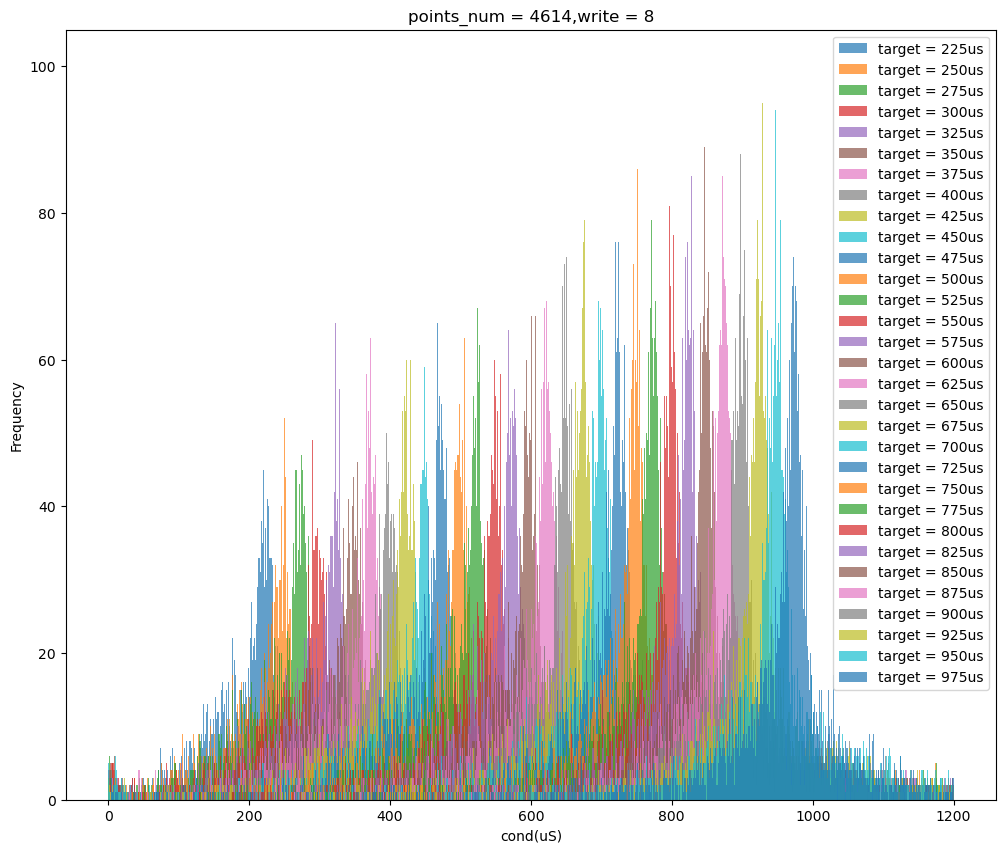

['./result/5bit精度/225us/after_write_verify_time=9.npy', './result/5bit精度/250us/after_write_verify_time=9.npy', './result/5bit精度/275us/after_write_verify_time=9.npy', './result/5bit精度/300us/after_write_verify_time=9.npy', './result/5bit精度/325us/after_write_verify_time=9.npy', './result/5bit精度/350us/after_write_verify_time=9.npy', './result/5bit精度/375us/after_write_verify_time=9.npy', './result/5bit精度/400us/after_write_verify_time=9.npy', './result/5bit精度/425us/after_write_verify_time=9.npy', './result/5bit精度/450us/after_write_verify_time=9.npy', './result/5bit精度/475us/after_write_verify_time=9.npy', './result/5bit精度/500us/after_write_verify_time=9.npy', './result/5bit精度/525us/after_write_verify_time=9.npy', './result/5bit精度/550us/after_write_verify_time=9.npy', './result/5bit精度/575us/after_write_verify_time=9.npy', './result/5bit精度/600us/after_write_verify_time=9.npy', './result/5bit精度/625us/after_write_verify_time=9.npy', './result/5bit精度/650us/after_write_verify_time=9.npy', './result

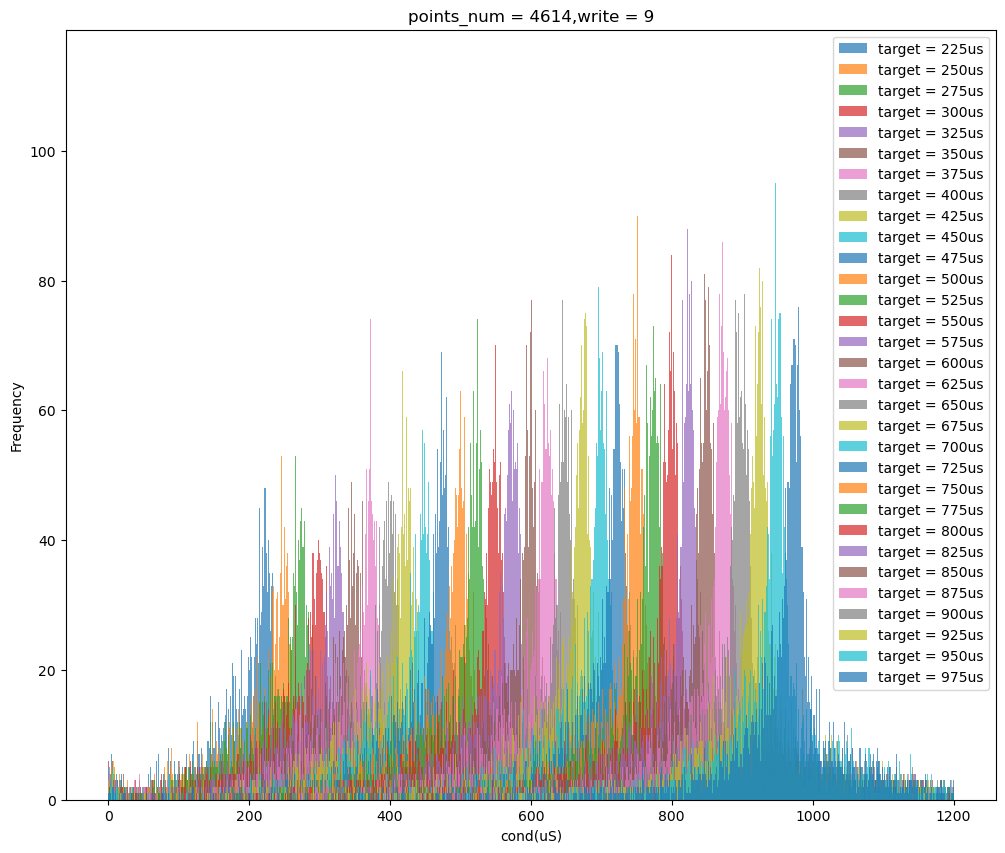

['./result/5bit精度/225us/after_write_verify_time=10.npy', './result/5bit精度/250us/after_write_verify_time=10.npy', './result/5bit精度/275us/after_write_verify_time=10.npy', './result/5bit精度/300us/after_write_verify_time=10.npy', './result/5bit精度/325us/after_write_verify_time=10.npy', './result/5bit精度/350us/after_write_verify_time=10.npy', './result/5bit精度/375us/after_write_verify_time=10.npy', './result/5bit精度/400us/after_write_verify_time=10.npy', './result/5bit精度/425us/after_write_verify_time=10.npy', './result/5bit精度/450us/after_write_verify_time=10.npy', './result/5bit精度/475us/after_write_verify_time=10.npy', './result/5bit精度/500us/after_write_verify_time=10.npy', './result/5bit精度/525us/after_write_verify_time=10.npy', './result/5bit精度/550us/after_write_verify_time=10.npy', './result/5bit精度/575us/after_write_verify_time=10.npy', './result/5bit精度/600us/after_write_verify_time=10.npy', './result/5bit精度/625us/after_write_verify_time=10.npy', './result/5bit精度/650us/after_write_verify_time=

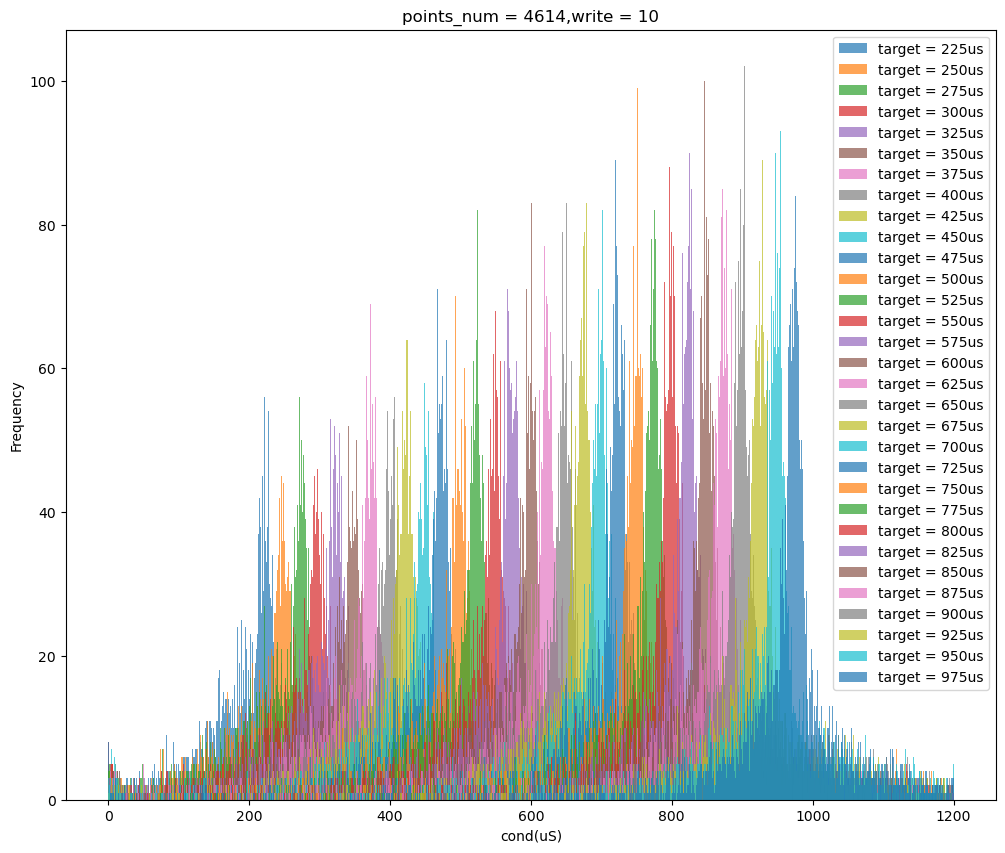

['./result/5bit精度/225us/after_write_verify_time=11.npy', './result/5bit精度/250us/after_write_verify_time=11.npy', './result/5bit精度/275us/after_write_verify_time=11.npy', './result/5bit精度/300us/after_write_verify_time=11.npy', './result/5bit精度/325us/after_write_verify_time=11.npy', './result/5bit精度/350us/after_write_verify_time=11.npy', './result/5bit精度/375us/after_write_verify_time=11.npy', './result/5bit精度/400us/after_write_verify_time=11.npy', './result/5bit精度/425us/after_write_verify_time=11.npy', './result/5bit精度/450us/after_write_verify_time=11.npy', './result/5bit精度/475us/after_write_verify_time=11.npy', './result/5bit精度/500us/after_write_verify_time=11.npy', './result/5bit精度/525us/after_write_verify_time=11.npy', './result/5bit精度/550us/after_write_verify_time=11.npy', './result/5bit精度/575us/after_write_verify_time=11.npy', './result/5bit精度/600us/after_write_verify_time=11.npy', './result/5bit精度/625us/after_write_verify_time=11.npy', './result/5bit精度/650us/after_write_verify_time=

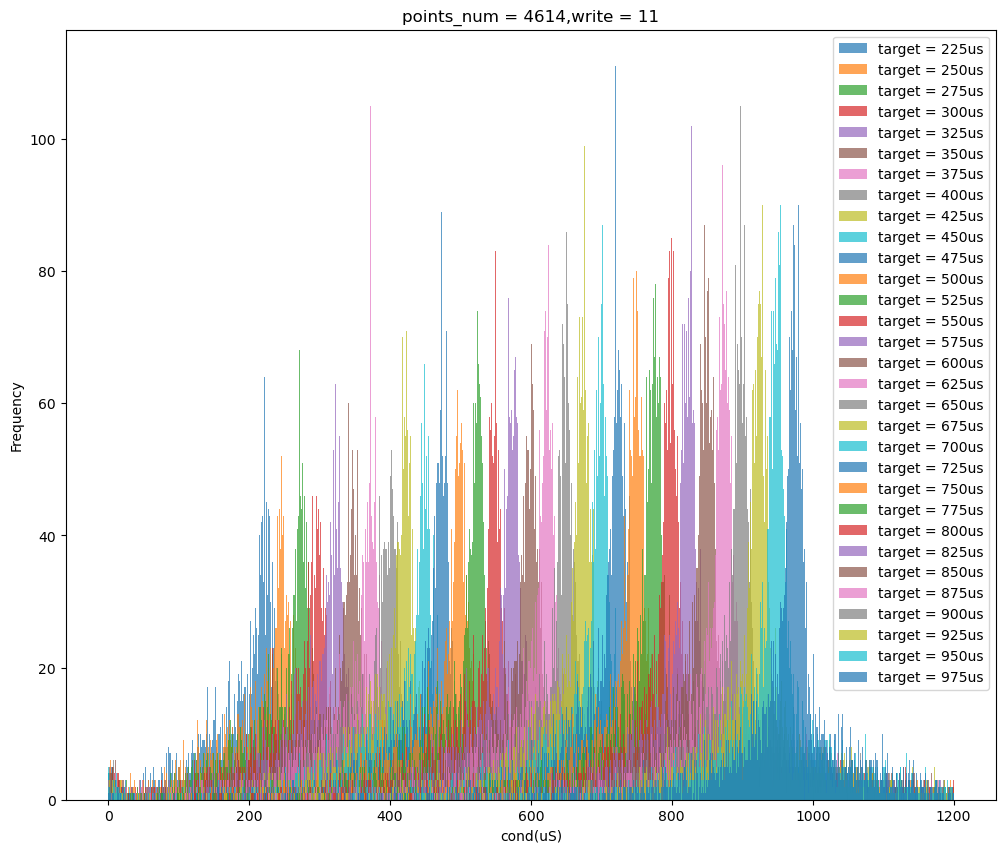

['./result/5bit精度/225us/after_write_verify_time=12.npy', './result/5bit精度/250us/after_write_verify_time=12.npy', './result/5bit精度/275us/after_write_verify_time=12.npy', './result/5bit精度/300us/after_write_verify_time=12.npy', './result/5bit精度/325us/after_write_verify_time=12.npy', './result/5bit精度/350us/after_write_verify_time=12.npy', './result/5bit精度/375us/after_write_verify_time=12.npy', './result/5bit精度/400us/after_write_verify_time=12.npy', './result/5bit精度/425us/after_write_verify_time=12.npy', './result/5bit精度/450us/after_write_verify_time=12.npy', './result/5bit精度/475us/after_write_verify_time=12.npy', './result/5bit精度/500us/after_write_verify_time=12.npy', './result/5bit精度/525us/after_write_verify_time=12.npy', './result/5bit精度/550us/after_write_verify_time=12.npy', './result/5bit精度/575us/after_write_verify_time=12.npy', './result/5bit精度/600us/after_write_verify_time=12.npy', './result/5bit精度/625us/after_write_verify_time=12.npy', './result/5bit精度/650us/after_write_verify_time=

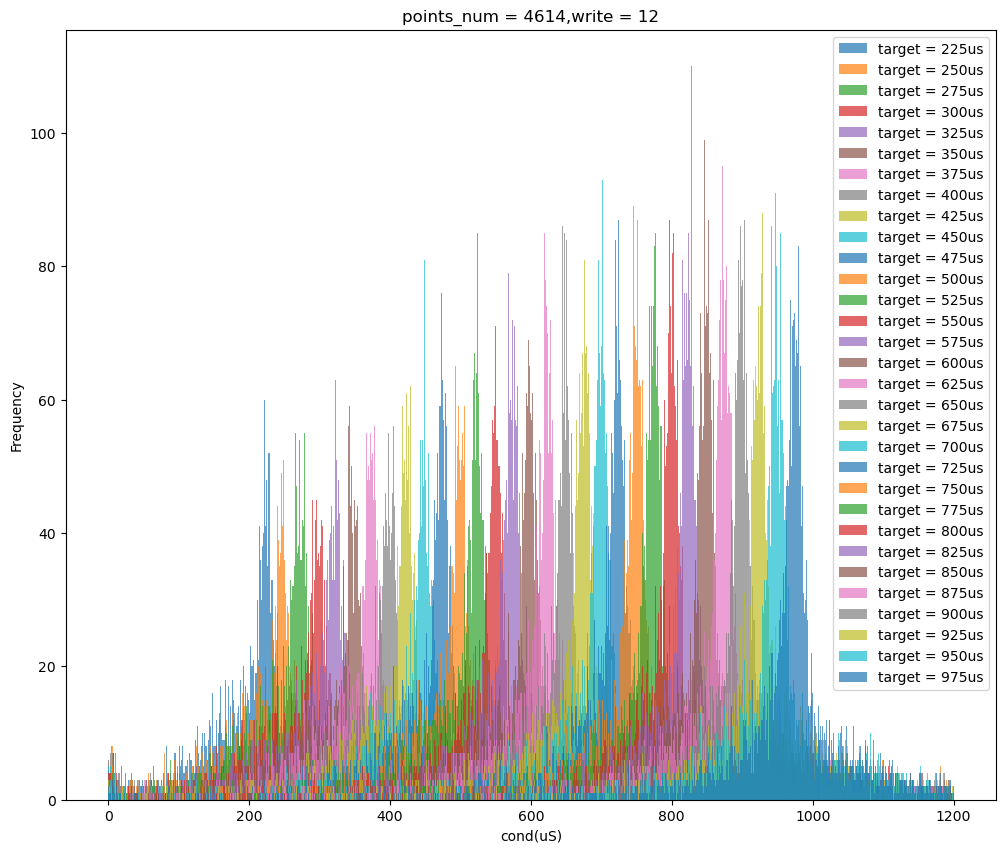

['./result/5bit精度/225us/after_write_verify_time=13.npy', './result/5bit精度/250us/after_write_verify_time=13.npy', './result/5bit精度/275us/after_write_verify_time=13.npy', './result/5bit精度/300us/after_write_verify_time=13.npy', './result/5bit精度/325us/after_write_verify_time=13.npy', './result/5bit精度/350us/after_write_verify_time=13.npy', './result/5bit精度/375us/after_write_verify_time=13.npy', './result/5bit精度/400us/after_write_verify_time=13.npy', './result/5bit精度/425us/after_write_verify_time=13.npy', './result/5bit精度/450us/after_write_verify_time=13.npy', './result/5bit精度/475us/after_write_verify_time=13.npy', './result/5bit精度/500us/after_write_verify_time=13.npy', './result/5bit精度/525us/after_write_verify_time=13.npy', './result/5bit精度/550us/after_write_verify_time=13.npy', './result/5bit精度/575us/after_write_verify_time=13.npy', './result/5bit精度/600us/after_write_verify_time=13.npy', './result/5bit精度/625us/after_write_verify_time=13.npy', './result/5bit精度/650us/after_write_verify_time=

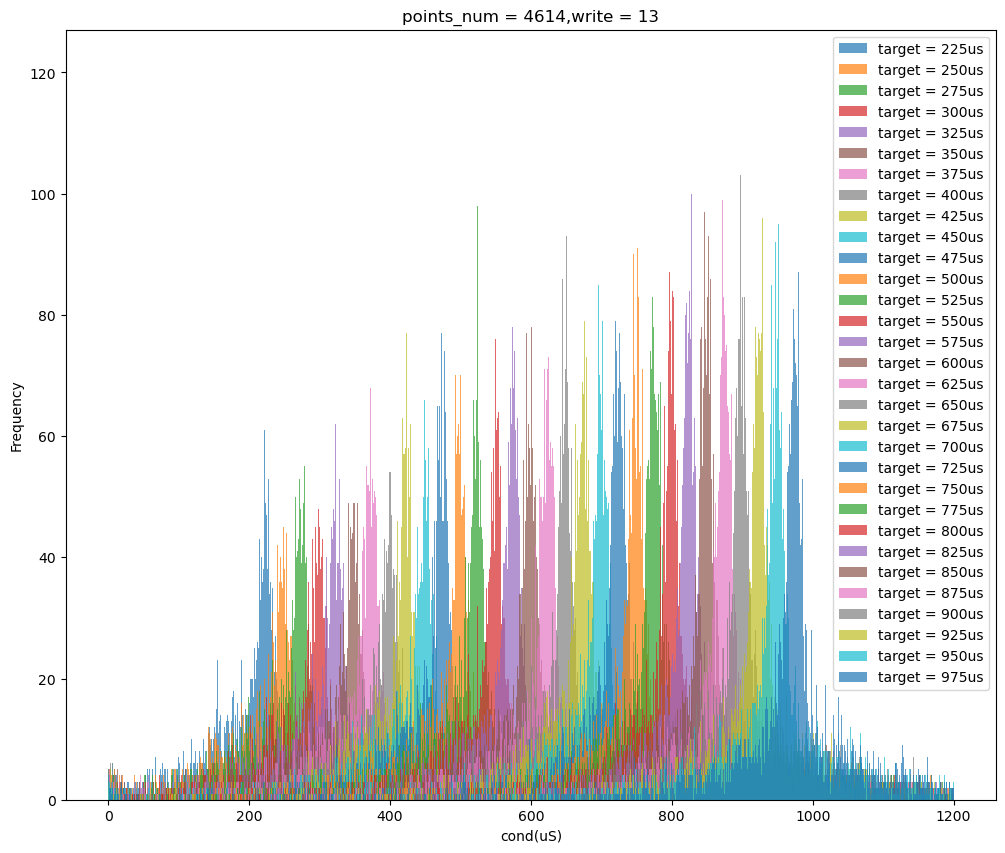

['./result/5bit精度/225us/after_write_verify_time=14.npy', './result/5bit精度/250us/after_write_verify_time=14.npy', './result/5bit精度/275us/after_write_verify_time=14.npy', './result/5bit精度/300us/after_write_verify_time=14.npy', './result/5bit精度/325us/after_write_verify_time=14.npy', './result/5bit精度/350us/after_write_verify_time=14.npy', './result/5bit精度/375us/after_write_verify_time=14.npy', './result/5bit精度/400us/after_write_verify_time=14.npy', './result/5bit精度/425us/after_write_verify_time=14.npy', './result/5bit精度/450us/after_write_verify_time=14.npy', './result/5bit精度/475us/after_write_verify_time=14.npy', './result/5bit精度/500us/after_write_verify_time=14.npy', './result/5bit精度/525us/after_write_verify_time=14.npy', './result/5bit精度/550us/after_write_verify_time=14.npy', './result/5bit精度/575us/after_write_verify_time=14.npy', './result/5bit精度/600us/after_write_verify_time=14.npy', './result/5bit精度/625us/after_write_verify_time=14.npy', './result/5bit精度/650us/after_write_verify_time=

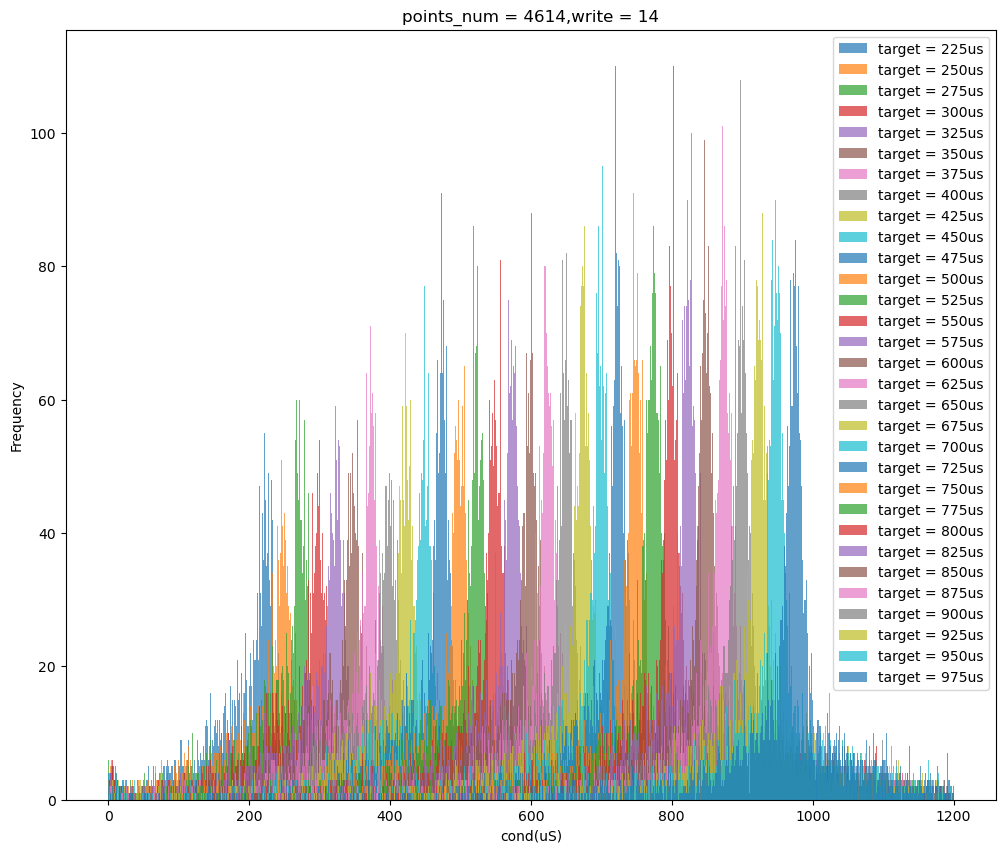

['./result/5bit精度/225us/after_write_verify_time=15.npy', './result/5bit精度/250us/after_write_verify_time=15.npy', './result/5bit精度/275us/after_write_verify_time=15.npy', './result/5bit精度/300us/after_write_verify_time=15.npy', './result/5bit精度/325us/after_write_verify_time=15.npy', './result/5bit精度/350us/after_write_verify_time=15.npy', './result/5bit精度/375us/after_write_verify_time=15.npy', './result/5bit精度/400us/after_write_verify_time=15.npy', './result/5bit精度/425us/after_write_verify_time=15.npy', './result/5bit精度/450us/after_write_verify_time=15.npy', './result/5bit精度/475us/after_write_verify_time=15.npy', './result/5bit精度/500us/after_write_verify_time=15.npy', './result/5bit精度/525us/after_write_verify_time=15.npy', './result/5bit精度/550us/after_write_verify_time=15.npy', './result/5bit精度/575us/after_write_verify_time=15.npy', './result/5bit精度/600us/after_write_verify_time=15.npy', './result/5bit精度/625us/after_write_verify_time=15.npy', './result/5bit精度/650us/after_write_verify_time=

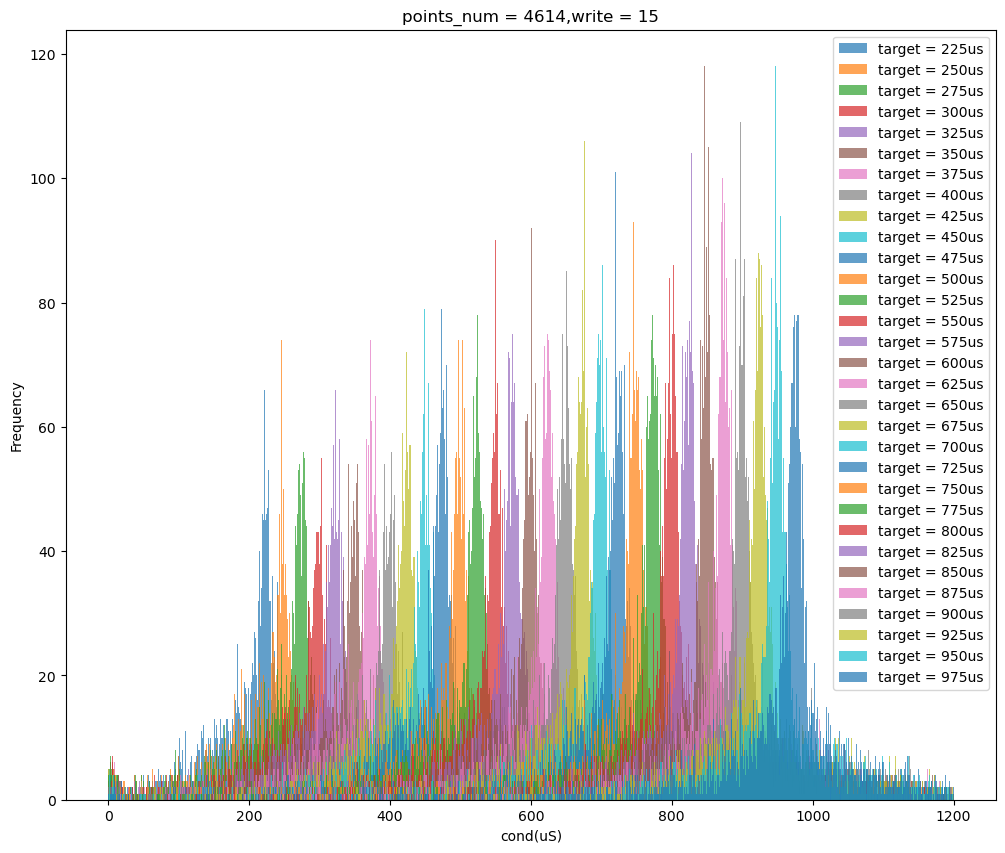

['./result/5bit精度/225us/after_write_verify_time=16.npy', './result/5bit精度/250us/after_write_verify_time=16.npy', './result/5bit精度/275us/after_write_verify_time=16.npy', './result/5bit精度/300us/after_write_verify_time=16.npy', './result/5bit精度/325us/after_write_verify_time=16.npy', './result/5bit精度/350us/after_write_verify_time=16.npy', './result/5bit精度/375us/after_write_verify_time=16.npy', './result/5bit精度/400us/after_write_verify_time=16.npy', './result/5bit精度/425us/after_write_verify_time=16.npy', './result/5bit精度/450us/after_write_verify_time=16.npy', './result/5bit精度/475us/after_write_verify_time=16.npy', './result/5bit精度/500us/after_write_verify_time=16.npy', './result/5bit精度/525us/after_write_verify_time=16.npy', './result/5bit精度/550us/after_write_verify_time=16.npy', './result/5bit精度/575us/after_write_verify_time=16.npy', './result/5bit精度/600us/after_write_verify_time=16.npy', './result/5bit精度/625us/after_write_verify_time=16.npy', './result/5bit精度/650us/after_write_verify_time=

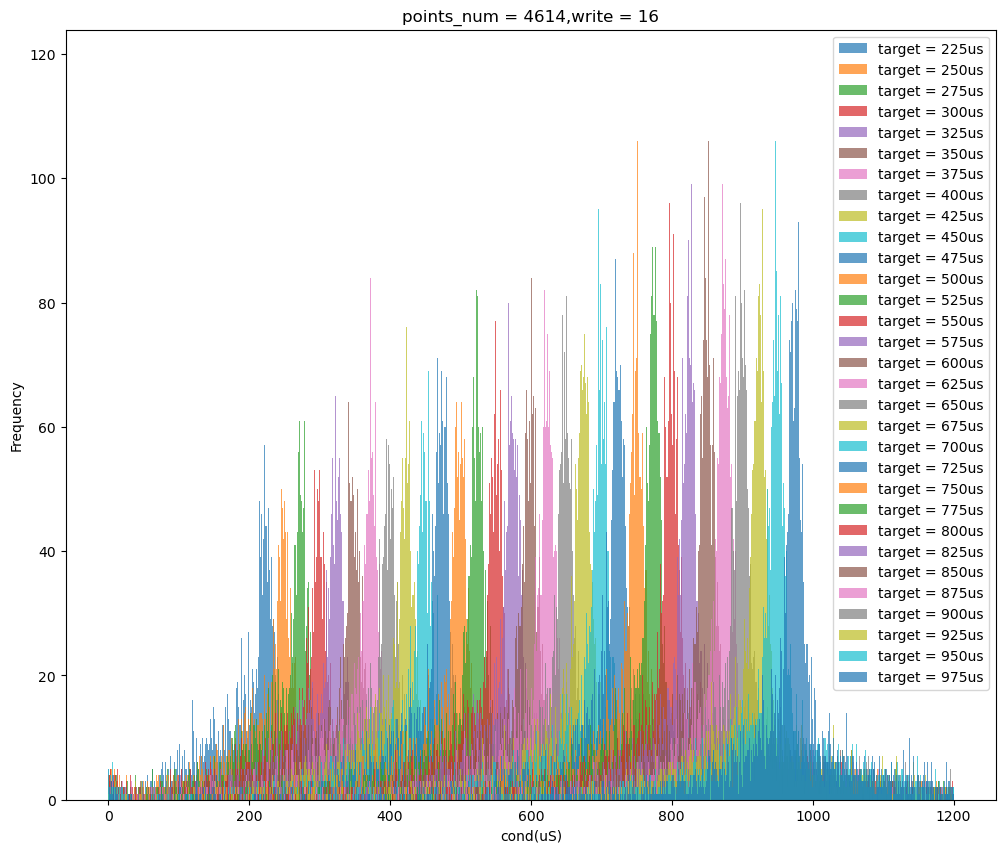

['./result/5bit精度/225us/after_write_verify_time=17.npy', './result/5bit精度/250us/after_write_verify_time=17.npy', './result/5bit精度/275us/after_write_verify_time=17.npy', './result/5bit精度/300us/after_write_verify_time=17.npy', './result/5bit精度/325us/after_write_verify_time=17.npy', './result/5bit精度/350us/after_write_verify_time=17.npy', './result/5bit精度/375us/after_write_verify_time=17.npy', './result/5bit精度/400us/after_write_verify_time=17.npy', './result/5bit精度/425us/after_write_verify_time=17.npy', './result/5bit精度/450us/after_write_verify_time=17.npy', './result/5bit精度/475us/after_write_verify_time=17.npy', './result/5bit精度/500us/after_write_verify_time=17.npy', './result/5bit精度/525us/after_write_verify_time=17.npy', './result/5bit精度/550us/after_write_verify_time=17.npy', './result/5bit精度/575us/after_write_verify_time=17.npy', './result/5bit精度/600us/after_write_verify_time=17.npy', './result/5bit精度/625us/after_write_verify_time=17.npy', './result/5bit精度/650us/after_write_verify_time=

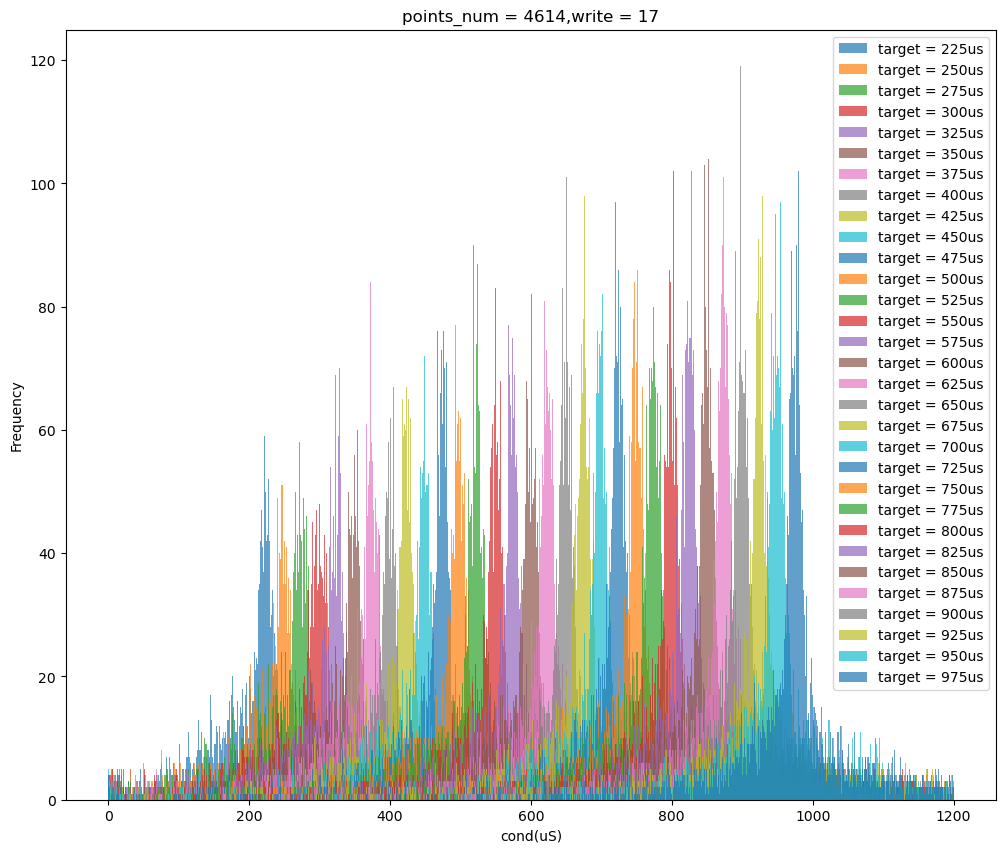

['./result/5bit精度/225us/after_write_verify_time=18.npy', './result/5bit精度/250us/after_write_verify_time=18.npy', './result/5bit精度/275us/after_write_verify_time=18.npy', './result/5bit精度/300us/after_write_verify_time=18.npy', './result/5bit精度/325us/after_write_verify_time=18.npy', './result/5bit精度/350us/after_write_verify_time=18.npy', './result/5bit精度/375us/after_write_verify_time=18.npy', './result/5bit精度/400us/after_write_verify_time=18.npy', './result/5bit精度/425us/after_write_verify_time=18.npy', './result/5bit精度/450us/after_write_verify_time=18.npy', './result/5bit精度/475us/after_write_verify_time=18.npy', './result/5bit精度/500us/after_write_verify_time=18.npy', './result/5bit精度/525us/after_write_verify_time=18.npy', './result/5bit精度/550us/after_write_verify_time=18.npy', './result/5bit精度/575us/after_write_verify_time=18.npy', './result/5bit精度/600us/after_write_verify_time=18.npy', './result/5bit精度/625us/after_write_verify_time=18.npy', './result/5bit精度/650us/after_write_verify_time=

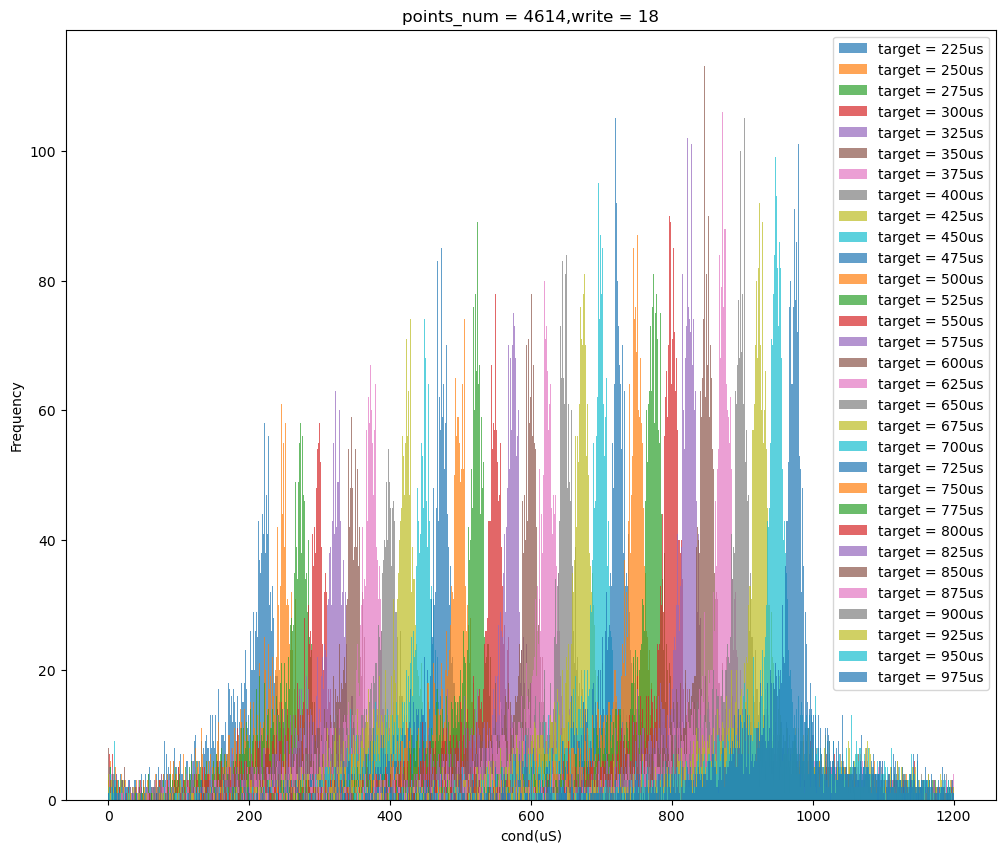

['./result/5bit精度/225us/after_write_verify_time=19.npy', './result/5bit精度/250us/after_write_verify_time=19.npy', './result/5bit精度/275us/after_write_verify_time=19.npy', './result/5bit精度/300us/after_write_verify_time=19.npy', './result/5bit精度/325us/after_write_verify_time=19.npy', './result/5bit精度/350us/after_write_verify_time=19.npy', './result/5bit精度/375us/after_write_verify_time=19.npy', './result/5bit精度/400us/after_write_verify_time=19.npy', './result/5bit精度/425us/after_write_verify_time=19.npy', './result/5bit精度/450us/after_write_verify_time=19.npy', './result/5bit精度/475us/after_write_verify_time=19.npy', './result/5bit精度/500us/after_write_verify_time=19.npy', './result/5bit精度/525us/after_write_verify_time=19.npy', './result/5bit精度/550us/after_write_verify_time=19.npy', './result/5bit精度/575us/after_write_verify_time=19.npy', './result/5bit精度/600us/after_write_verify_time=19.npy', './result/5bit精度/625us/after_write_verify_time=19.npy', './result/5bit精度/650us/after_write_verify_time=

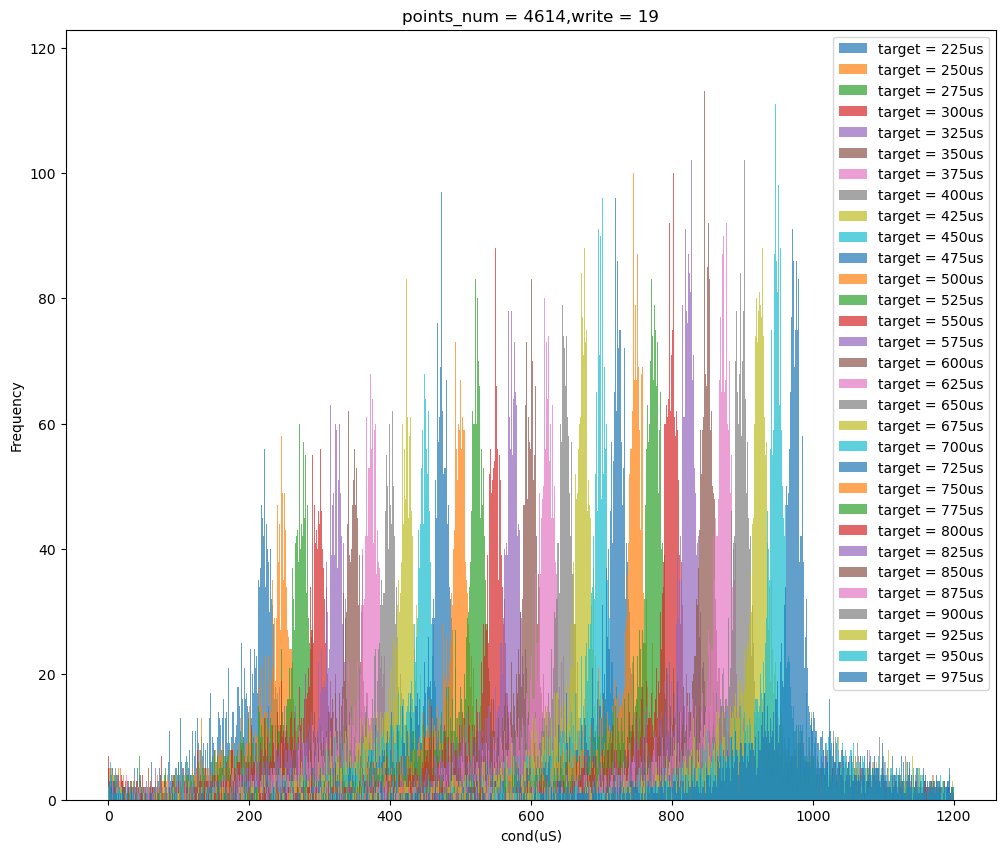

['./result/5bit精度/225us/after_write_verify_time=20.npy', './result/5bit精度/250us/after_write_verify_time=20.npy', './result/5bit精度/275us/after_write_verify_time=20.npy', './result/5bit精度/300us/after_write_verify_time=20.npy', './result/5bit精度/325us/after_write_verify_time=20.npy', './result/5bit精度/350us/after_write_verify_time=20.npy', './result/5bit精度/375us/after_write_verify_time=20.npy', './result/5bit精度/400us/after_write_verify_time=20.npy', './result/5bit精度/425us/after_write_verify_time=20.npy', './result/5bit精度/450us/after_write_verify_time=20.npy', './result/5bit精度/475us/after_write_verify_time=20.npy', './result/5bit精度/500us/after_write_verify_time=20.npy', './result/5bit精度/525us/after_write_verify_time=20.npy', './result/5bit精度/550us/after_write_verify_time=20.npy', './result/5bit精度/575us/after_write_verify_time=20.npy', './result/5bit精度/600us/after_write_verify_time=20.npy', './result/5bit精度/625us/after_write_verify_time=20.npy', './result/5bit精度/650us/after_write_verify_time=

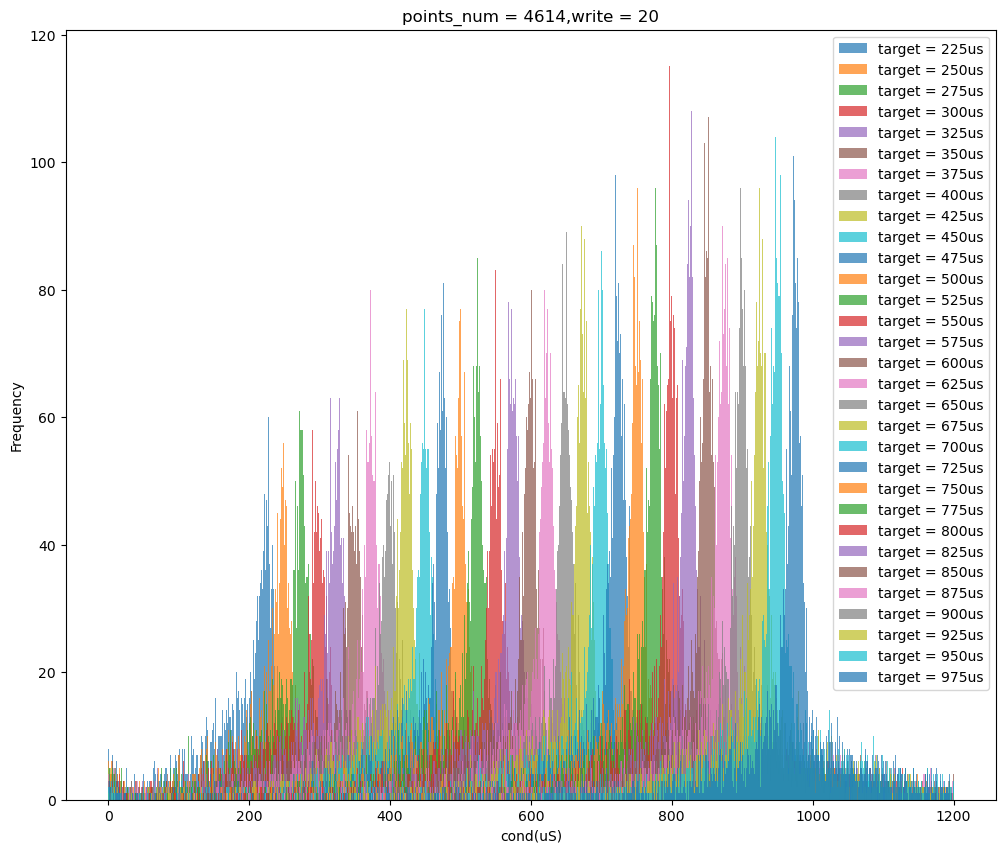

['./result/5bit精度/225us/after_write_verify_time=21.npy', './result/5bit精度/250us/after_write_verify_time=21.npy', './result/5bit精度/275us/after_write_verify_time=21.npy', './result/5bit精度/300us/after_write_verify_time=21.npy', './result/5bit精度/325us/after_write_verify_time=21.npy', './result/5bit精度/350us/after_write_verify_time=21.npy', './result/5bit精度/375us/after_write_verify_time=21.npy', './result/5bit精度/400us/after_write_verify_time=21.npy', './result/5bit精度/425us/after_write_verify_time=21.npy', './result/5bit精度/450us/after_write_verify_time=21.npy', './result/5bit精度/475us/after_write_verify_time=21.npy', './result/5bit精度/500us/after_write_verify_time=21.npy', './result/5bit精度/525us/after_write_verify_time=21.npy', './result/5bit精度/550us/after_write_verify_time=21.npy', './result/5bit精度/575us/after_write_verify_time=21.npy', './result/5bit精度/600us/after_write_verify_time=21.npy', './result/5bit精度/625us/after_write_verify_time=21.npy', './result/5bit精度/650us/after_write_verify_time=

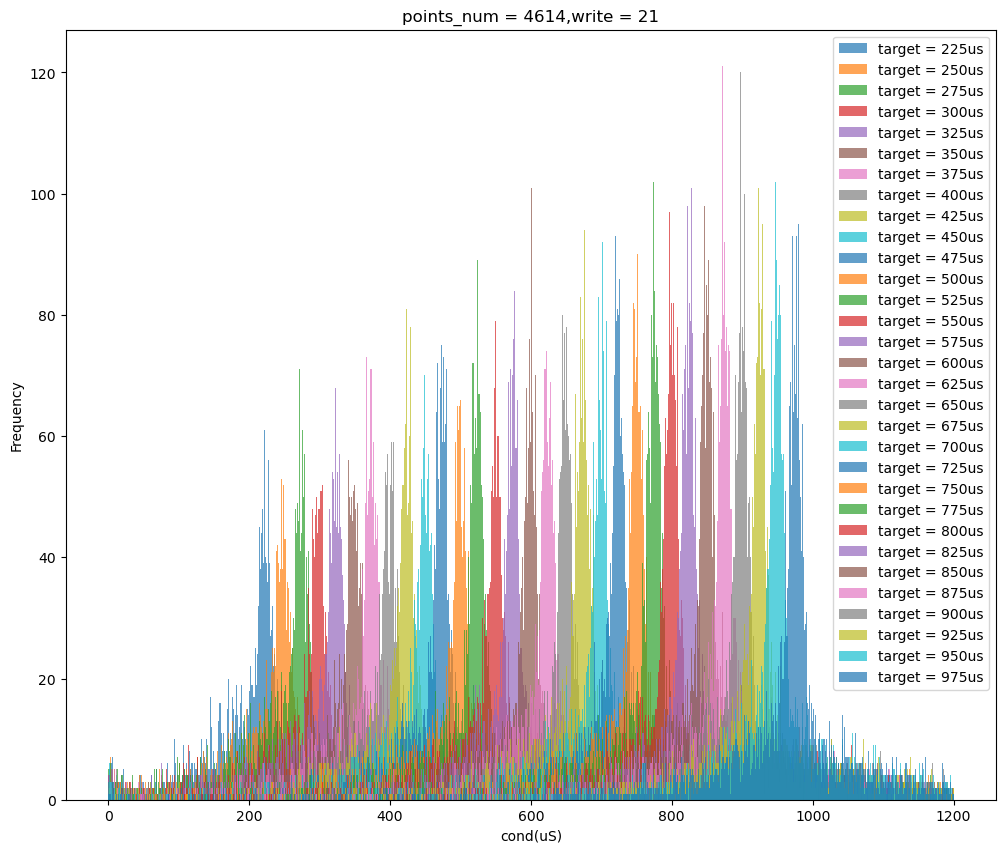

['./result/5bit精度/225us/after_write_verify_time=22.npy', './result/5bit精度/250us/after_write_verify_time=22.npy', './result/5bit精度/275us/after_write_verify_time=22.npy', './result/5bit精度/300us/after_write_verify_time=22.npy', './result/5bit精度/325us/after_write_verify_time=22.npy', './result/5bit精度/350us/after_write_verify_time=22.npy', './result/5bit精度/375us/after_write_verify_time=22.npy', './result/5bit精度/400us/after_write_verify_time=22.npy', './result/5bit精度/425us/after_write_verify_time=22.npy', './result/5bit精度/450us/after_write_verify_time=22.npy', './result/5bit精度/475us/after_write_verify_time=22.npy', './result/5bit精度/500us/after_write_verify_time=22.npy', './result/5bit精度/525us/after_write_verify_time=22.npy', './result/5bit精度/550us/after_write_verify_time=22.npy', './result/5bit精度/575us/after_write_verify_time=22.npy', './result/5bit精度/600us/after_write_verify_time=22.npy', './result/5bit精度/625us/after_write_verify_time=22.npy', './result/5bit精度/650us/after_write_verify_time=

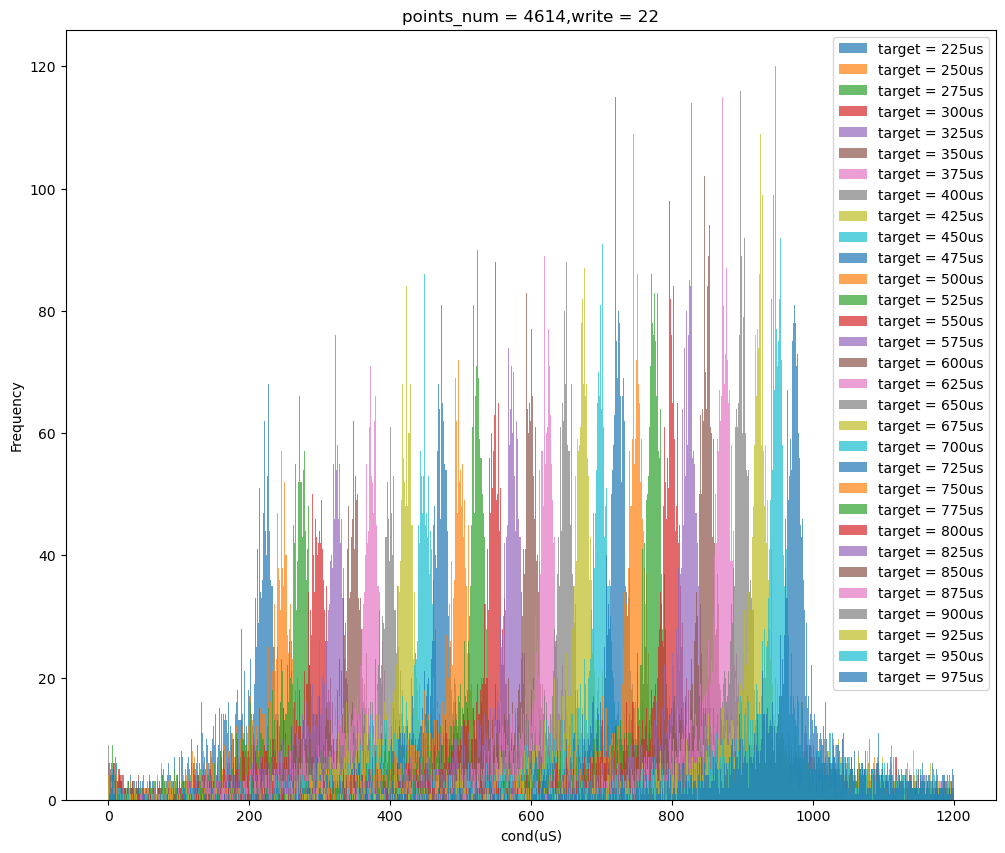

['./result/5bit精度/225us/after_write_verify_time=23.npy', './result/5bit精度/250us/after_write_verify_time=23.npy', './result/5bit精度/275us/after_write_verify_time=23.npy', './result/5bit精度/300us/after_write_verify_time=23.npy', './result/5bit精度/325us/after_write_verify_time=23.npy', './result/5bit精度/350us/after_write_verify_time=23.npy', './result/5bit精度/375us/after_write_verify_time=23.npy', './result/5bit精度/400us/after_write_verify_time=23.npy', './result/5bit精度/425us/after_write_verify_time=23.npy', './result/5bit精度/450us/after_write_verify_time=23.npy', './result/5bit精度/475us/after_write_verify_time=23.npy', './result/5bit精度/500us/after_write_verify_time=23.npy', './result/5bit精度/525us/after_write_verify_time=23.npy', './result/5bit精度/550us/after_write_verify_time=23.npy', './result/5bit精度/575us/after_write_verify_time=23.npy', './result/5bit精度/600us/after_write_verify_time=23.npy', './result/5bit精度/625us/after_write_verify_time=23.npy', './result/5bit精度/650us/after_write_verify_time=

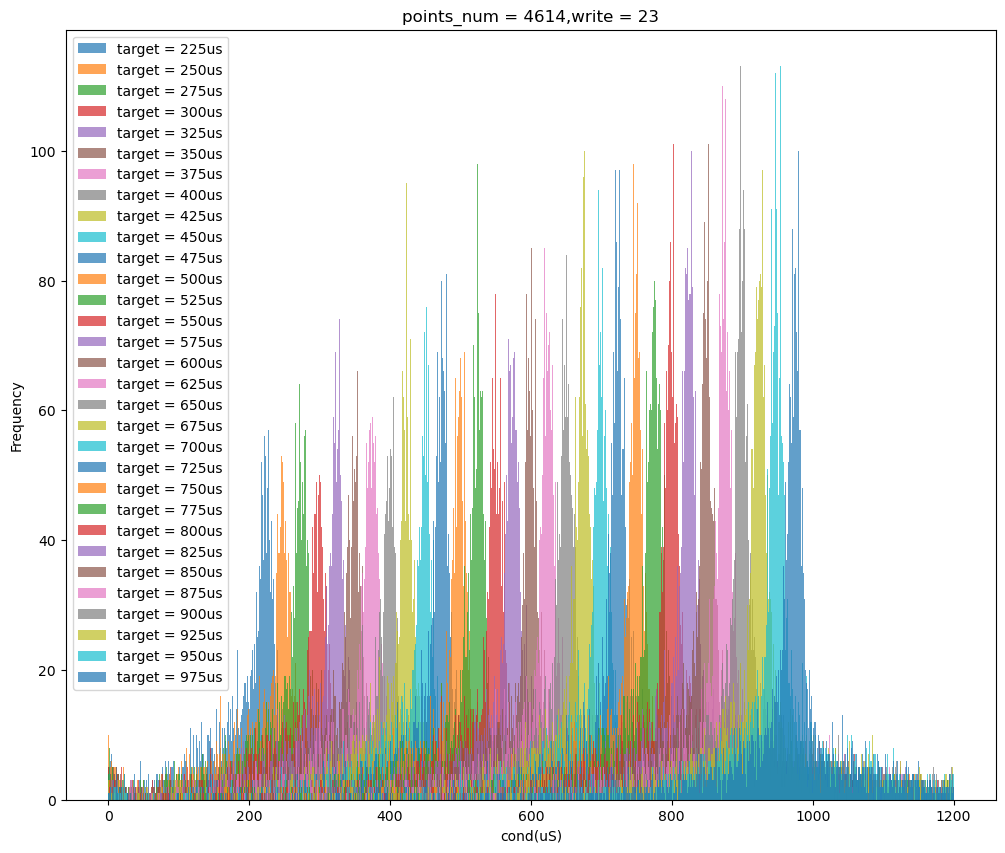

['./result/5bit精度/225us/after_write_verify_time=24.npy', './result/5bit精度/250us/after_write_verify_time=24.npy', './result/5bit精度/275us/after_write_verify_time=24.npy', './result/5bit精度/300us/after_write_verify_time=24.npy', './result/5bit精度/325us/after_write_verify_time=24.npy', './result/5bit精度/350us/after_write_verify_time=24.npy', './result/5bit精度/375us/after_write_verify_time=24.npy', './result/5bit精度/400us/after_write_verify_time=24.npy', './result/5bit精度/425us/after_write_verify_time=24.npy', './result/5bit精度/450us/after_write_verify_time=24.npy', './result/5bit精度/475us/after_write_verify_time=24.npy', './result/5bit精度/500us/after_write_verify_time=24.npy', './result/5bit精度/525us/after_write_verify_time=24.npy', './result/5bit精度/550us/after_write_verify_time=24.npy', './result/5bit精度/575us/after_write_verify_time=24.npy', './result/5bit精度/600us/after_write_verify_time=24.npy', './result/5bit精度/625us/after_write_verify_time=24.npy', './result/5bit精度/650us/after_write_verify_time=

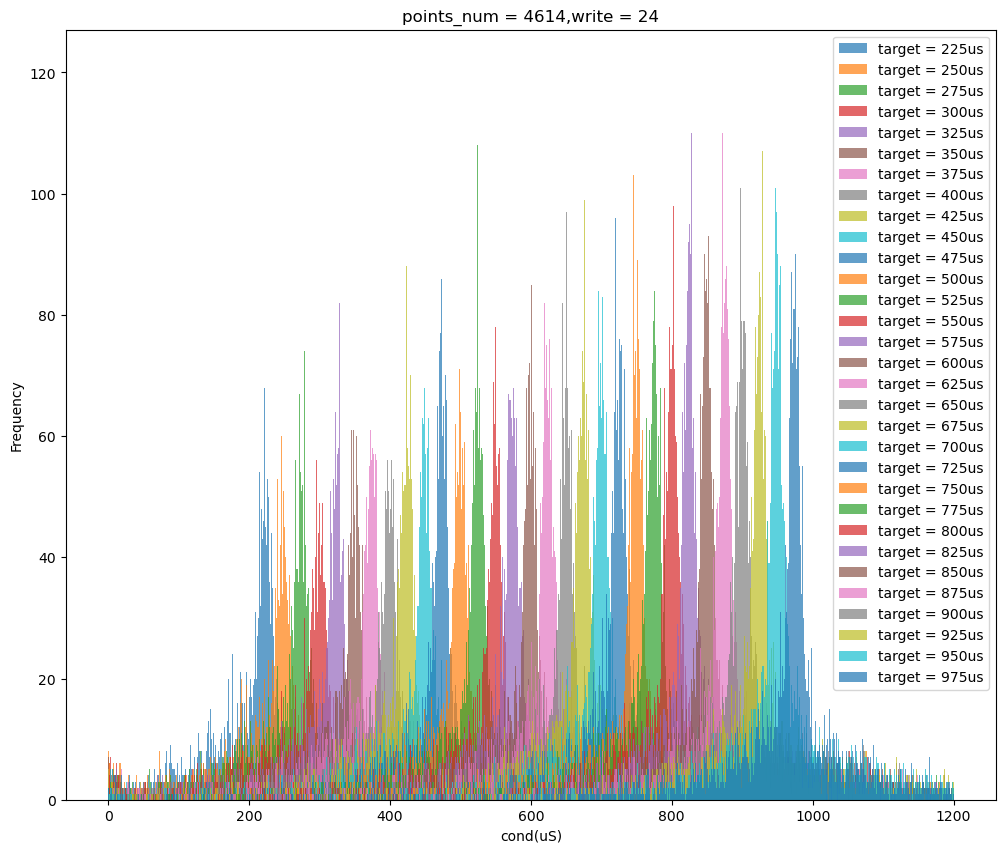

['./result/5bit精度/225us/after_write_verify_time=25.npy', './result/5bit精度/250us/after_write_verify_time=25.npy', './result/5bit精度/275us/after_write_verify_time=25.npy', './result/5bit精度/300us/after_write_verify_time=25.npy', './result/5bit精度/325us/after_write_verify_time=25.npy', './result/5bit精度/350us/after_write_verify_time=25.npy', './result/5bit精度/375us/after_write_verify_time=25.npy', './result/5bit精度/400us/after_write_verify_time=25.npy', './result/5bit精度/425us/after_write_verify_time=25.npy', './result/5bit精度/450us/after_write_verify_time=25.npy', './result/5bit精度/475us/after_write_verify_time=25.npy', './result/5bit精度/500us/after_write_verify_time=25.npy', './result/5bit精度/525us/after_write_verify_time=25.npy', './result/5bit精度/550us/after_write_verify_time=25.npy', './result/5bit精度/575us/after_write_verify_time=25.npy', './result/5bit精度/600us/after_write_verify_time=25.npy', './result/5bit精度/625us/after_write_verify_time=25.npy', './result/5bit精度/650us/after_write_verify_time=

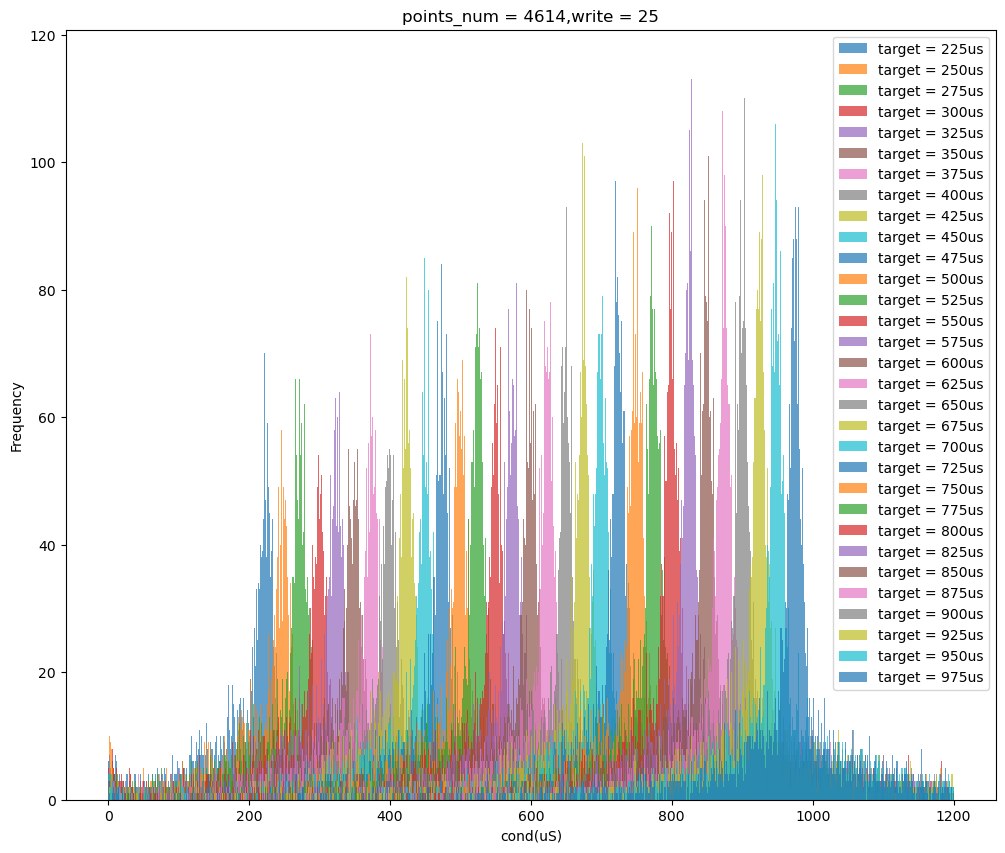

['./result/5bit精度/225us/after_write_verify_time=26.npy', './result/5bit精度/250us/after_write_verify_time=26.npy', './result/5bit精度/275us/after_write_verify_time=26.npy', './result/5bit精度/300us/after_write_verify_time=26.npy', './result/5bit精度/325us/after_write_verify_time=26.npy', './result/5bit精度/350us/after_write_verify_time=26.npy', './result/5bit精度/375us/after_write_verify_time=26.npy', './result/5bit精度/400us/after_write_verify_time=26.npy', './result/5bit精度/425us/after_write_verify_time=26.npy', './result/5bit精度/450us/after_write_verify_time=26.npy', './result/5bit精度/475us/after_write_verify_time=26.npy', './result/5bit精度/500us/after_write_verify_time=26.npy', './result/5bit精度/525us/after_write_verify_time=26.npy', './result/5bit精度/550us/after_write_verify_time=26.npy', './result/5bit精度/575us/after_write_verify_time=26.npy', './result/5bit精度/600us/after_write_verify_time=26.npy', './result/5bit精度/625us/after_write_verify_time=26.npy', './result/5bit精度/650us/after_write_verify_time=

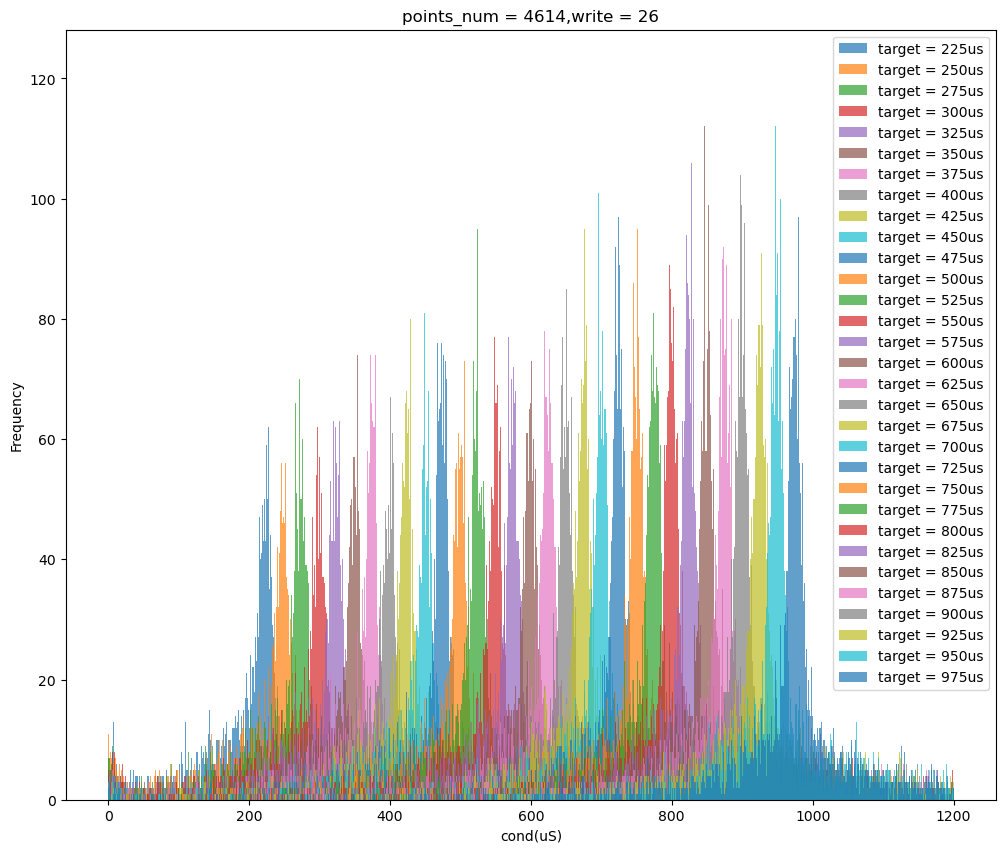

['./result/5bit精度/225us/after_write_verify_time=27.npy', './result/5bit精度/250us/after_write_verify_time=27.npy', './result/5bit精度/275us/after_write_verify_time=27.npy', './result/5bit精度/300us/after_write_verify_time=27.npy', './result/5bit精度/325us/after_write_verify_time=27.npy', './result/5bit精度/350us/after_write_verify_time=27.npy', './result/5bit精度/375us/after_write_verify_time=27.npy', './result/5bit精度/400us/after_write_verify_time=27.npy', './result/5bit精度/425us/after_write_verify_time=27.npy', './result/5bit精度/450us/after_write_verify_time=27.npy', './result/5bit精度/475us/after_write_verify_time=27.npy', './result/5bit精度/500us/after_write_verify_time=27.npy', './result/5bit精度/525us/after_write_verify_time=27.npy', './result/5bit精度/550us/after_write_verify_time=27.npy', './result/5bit精度/575us/after_write_verify_time=27.npy', './result/5bit精度/600us/after_write_verify_time=27.npy', './result/5bit精度/625us/after_write_verify_time=27.npy', './result/5bit精度/650us/after_write_verify_time=

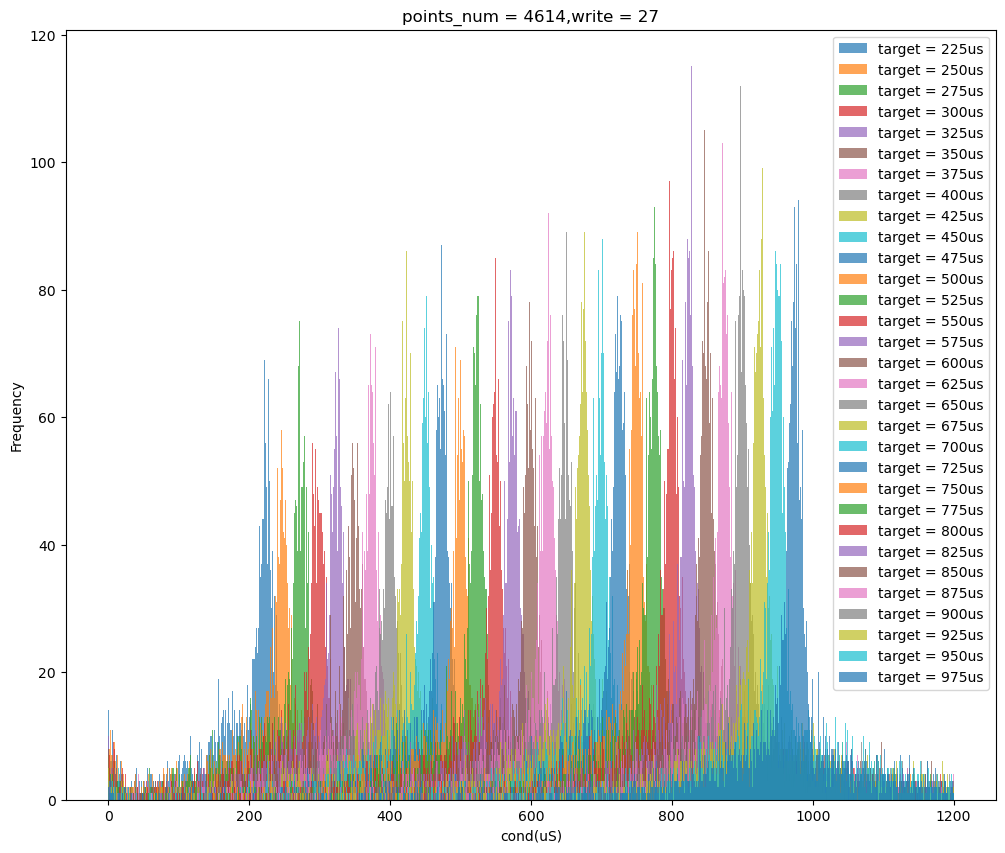

['./result/5bit精度/225us/after_write_verify_time=28.npy', './result/5bit精度/250us/after_write_verify_time=28.npy', './result/5bit精度/275us/after_write_verify_time=28.npy', './result/5bit精度/300us/after_write_verify_time=28.npy', './result/5bit精度/325us/after_write_verify_time=28.npy', './result/5bit精度/350us/after_write_verify_time=28.npy', './result/5bit精度/375us/after_write_verify_time=28.npy', './result/5bit精度/400us/after_write_verify_time=28.npy', './result/5bit精度/425us/after_write_verify_time=28.npy', './result/5bit精度/450us/after_write_verify_time=28.npy', './result/5bit精度/475us/after_write_verify_time=28.npy', './result/5bit精度/500us/after_write_verify_time=28.npy', './result/5bit精度/525us/after_write_verify_time=28.npy', './result/5bit精度/550us/after_write_verify_time=28.npy', './result/5bit精度/575us/after_write_verify_time=28.npy', './result/5bit精度/600us/after_write_verify_time=28.npy', './result/5bit精度/625us/after_write_verify_time=28.npy', './result/5bit精度/650us/after_write_verify_time=

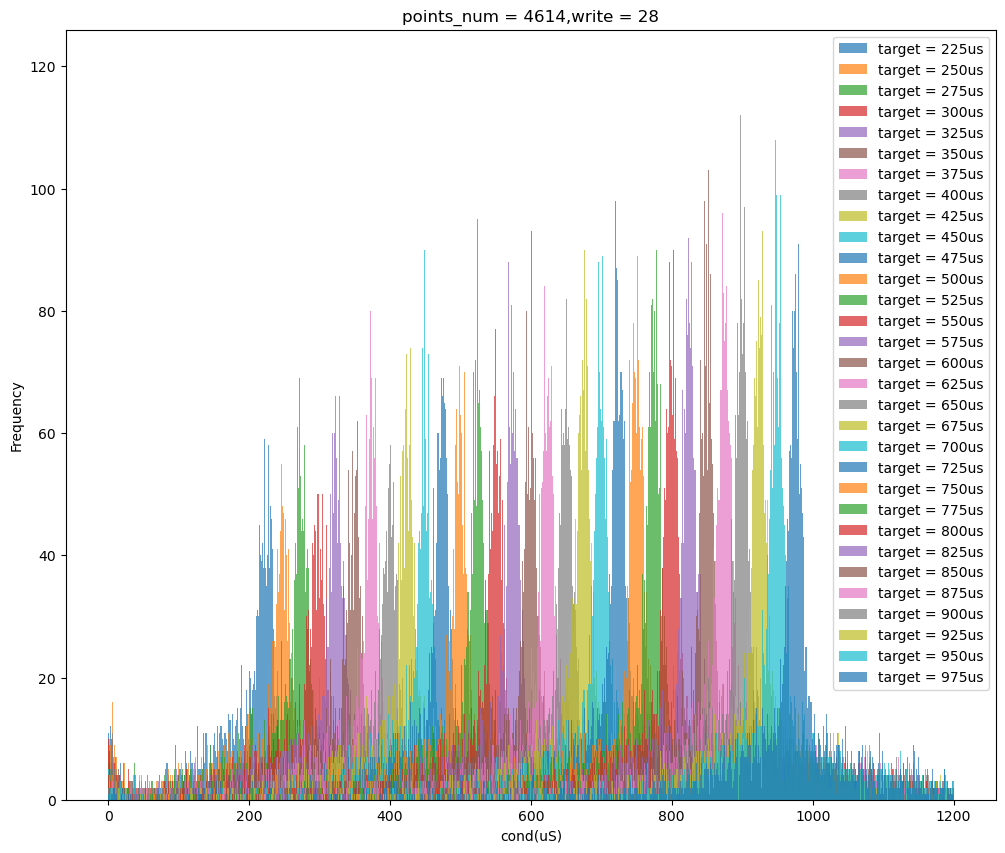

['./result/5bit精度/225us/after_write_verify_time=29.npy', './result/5bit精度/250us/after_write_verify_time=29.npy', './result/5bit精度/275us/after_write_verify_time=29.npy', './result/5bit精度/300us/after_write_verify_time=29.npy', './result/5bit精度/325us/after_write_verify_time=29.npy', './result/5bit精度/350us/after_write_verify_time=29.npy', './result/5bit精度/375us/after_write_verify_time=29.npy', './result/5bit精度/400us/after_write_verify_time=29.npy', './result/5bit精度/425us/after_write_verify_time=29.npy', './result/5bit精度/450us/after_write_verify_time=29.npy', './result/5bit精度/475us/after_write_verify_time=29.npy', './result/5bit精度/500us/after_write_verify_time=29.npy', './result/5bit精度/525us/after_write_verify_time=29.npy', './result/5bit精度/550us/after_write_verify_time=29.npy', './result/5bit精度/575us/after_write_verify_time=29.npy', './result/5bit精度/600us/after_write_verify_time=29.npy', './result/5bit精度/625us/after_write_verify_time=29.npy', './result/5bit精度/650us/after_write_verify_time=

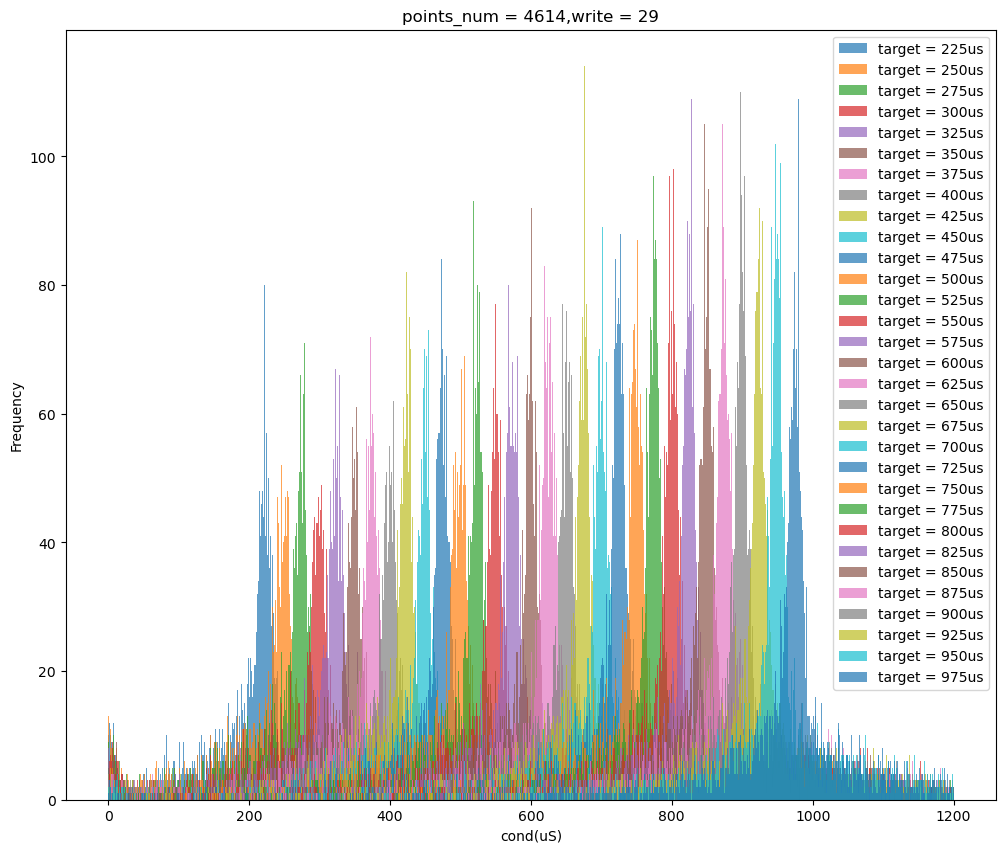

['./result/5bit精度/225us/after_write_verify_time=30.npy', './result/5bit精度/250us/after_write_verify_time=30.npy', './result/5bit精度/275us/after_write_verify_time=30.npy', './result/5bit精度/300us/after_write_verify_time=30.npy', './result/5bit精度/325us/after_write_verify_time=30.npy', './result/5bit精度/350us/after_write_verify_time=30.npy', './result/5bit精度/375us/after_write_verify_time=30.npy', './result/5bit精度/400us/after_write_verify_time=30.npy', './result/5bit精度/425us/after_write_verify_time=30.npy', './result/5bit精度/450us/after_write_verify_time=30.npy', './result/5bit精度/475us/after_write_verify_time=30.npy', './result/5bit精度/500us/after_write_verify_time=30.npy', './result/5bit精度/525us/after_write_verify_time=30.npy', './result/5bit精度/550us/after_write_verify_time=30.npy', './result/5bit精度/575us/after_write_verify_time=30.npy', './result/5bit精度/600us/after_write_verify_time=30.npy', './result/5bit精度/625us/after_write_verify_time=30.npy', './result/5bit精度/650us/after_write_verify_time=

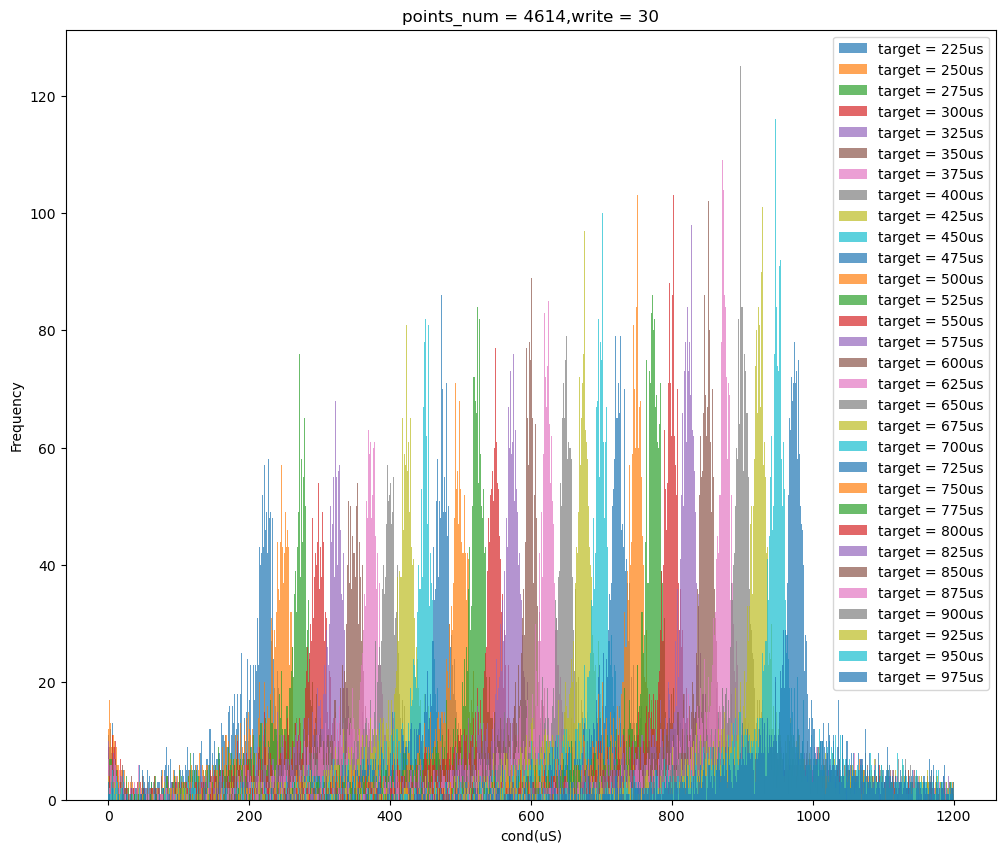

In [4]:
times = 30
for times in range(1,31):
    target = 175
    cond_sub_base_path = []
    good_device_path = []
    for i in range(16):
        target = target+50

        root_path=f"./result/5bit精度/{target}us/"
        cond_sub_base_path.append(root_path+f"after_write_verify_time={times}.npy")
        good_device_path.append(root_path+"good_device.npy")

        if target+25 <1000:
            root_path=f"./result/5bit精度/{target+25}us/"
            cond_sub_base_path.append(root_path+f"after_write_verify_time={times}.npy")
            good_device_path.append(root_path+"good_device.npy")
    print(cond_sub_base_path)
    print(good_device_path)
    # 设置直方图的区间
    interval = 1
    bin_edges = np.linspace(0, 1200, int(1200 / interval) + 1)

    plt.figure(figsize=(12,10))

    for i, path in enumerate(cond_sub_base_path):
        good_device = np.load(good_device_path[i])
        cond_sub_base = np.load(path)[good_device]
        data = cond_sub_base.flatten()
        counts, bin_edges, _ = plt.hist(data, bins=bin_edges, alpha=0.7, edgecolor='none', label=f"target = {225+25*i}us")

    plt.legend()
    plt.xlabel("cond(uS)")
    plt.ylabel("Frequency")
    plt.title(f"points_num = {4614},write = {times}")

    plt.savefig("./result/器件性能5bit/"+f"points_num = {4614},write = {times}.png")
    # 显示图形
    plt.show()

In [ ]:
target = 500
cond_sub_base_path = []
root_path=f"./result/精度/{target}us/"
for i in range(40):
    cond_sub_base_path.append(root_path+f"after_write_verify_time={int(i)}.npy")
print(cond_sub_base_path)

In [ ]:
# good_device = np.load("good_device.npy")

In [ ]:
interval = 5
bin_edges = np.linspace(0, 2000, int(2000/interval)+1)  
for i,path in enumerate(cond_sub_base_path):
    cond_sub_base = np.load(path)#[good_device]
    data = cond_sub_base.flatten()
    counts, bin_edges, _ = plt.hist(data, bins=bin_edges, color='blue', alpha=0.7, edgecolor='black')
    plt.title(f"target = {target},write = {i}")
    plt.xlabel("cond(uS)")
    plt.ylabel("Frequency")
    path = root_path+f"target = {target},write = {i}.png"
    plt.savefig(path)
    plt.show()